## Librerias e Importacion de Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from scipy import stats
import statistics

sys.path.insert(0, ". . ")
from funciones.dominios import cargar_dominio
from funciones.campos import normalizar_dtypes
from funciones.graficos_avanzado import (
    plot_customer_journey,
    analisis_productos_frecuencia,
    analisis_producto_ticket,
    analisis_combinaciones_volumen,
    analisis_potencial_crecimiento,
    analisis_next_best_product,
)
from funciones.cross_sell_simulator import CrossSellSimulator, FiltrosElegibilidad

sns.set_theme(style="whitegrid", palette="husl")

In [2]:
_DATA_PATH = 'data'

clientes_df = pd.read_csv(f'{_DATA_PATH}/clientes.csv')
catalogo_productos_df = pd.read_csv(f'{_DATA_PATH}/catalogo_productos.csv')
transacciones_df = pd.read_csv(f'{_DATA_PATH}/transacciones.csv')

In [3]:
# Flujo completo: normalizar dtypes -> auditar -> construir objetos OOP
dominio = cargar_dominio(clientes_df, catalogo_productos_df, transacciones_df)


RESUMEN GENERAL -> clientes
Filas: 100
Columnas: 6

Columnas:
['id_cliente', 'nombre', 'edad', 'genero', 'pais', 'segmento']

Tipos de datos:
id_cliente     int64
nombre        object
edad           int64
genero        object
pais          object
segmento      object
dtype: object

Primeras filas:
   id_cliente        nombre  edad genero       pais     segmento
0        1001  Cliente_1001    49      F      Chile       Retail
1        1002  Cliente_1002    32      M      Chile  Corporativo
2        1003  Cliente_1003    20      M  Argentina         PYME
3        1004  Cliente_1004    55      F     México         PYME
4        1005  Cliente_1005    43      F     México         PYME

--------------------------------------------------------------------------------
NULOS -> clientes
--------------------------------------------------------------------------------
            nulos  porcentaje_%
id_cliente      0           0.0
nombre          0           0.0
edad            0           0.0
g

In [4]:
# Explorar el dominio
print(f'Clientes: {len(dominio.clientes)}')
print(f'Productos: {len(dominio.productos)}')
print(f'Transacciones: {len(dominio.transacciones)}')
print(f'Data válida: {dominio.es_valido}')

# Navegación por objetos
t = dominio.transacciones[0]
print(f"\nTransaccion {t.id_transaccion}: {t.cliente.nombre} -> {t.producto.nombre_producto} ({t.monto:,.2f} {t.producto.moneda} | {t.monto_usd:,.2f} USD)\n")

# Buscar cliente por ID (Rango de 1000 a 1100)
c = dominio.cliente(1100)
print(f'\nCliente {c.id_cliente}: {c.nombre}, {c.edad} años, {len(c.transacciones)} transacciones')


Clientes: 100
Productos: 10
Transacciones: 500
Data válida: True

Transaccion 5001: Cliente_1046 -> Producto_7 (1,539.59 EUR | 1,790.22 USD)


Cliente 1100: Cliente_1100, 45 años, 5 transacciones


In [5]:
# Total de Transacciones en USD
total_usd = sum([t.monto_usd for t in dominio.transacciones])
print(f"Total Transacciones en USD: ${total_usd:,.2f}\n")

# Lista de configuraciones para cada desglose: (Titulo a imprimir, función lambda para extraer el dato)
desgloses = [
    ("Tipo de Transacción", lambda t: t.tipo_transaccion),
    ("Tipo de Producto", lambda t: t.producto.tipo_producto),
    ("Segmento", lambda t: t.cliente.segmento),
    ("País", lambda t: t.cliente.pais),
    ("Sexo", lambda t: t.cliente.genero),
    ("Producto", lambda t: t.producto.nombre_producto)
]

# Ejecutar el conteo y la suma para cada criterio de desglose
for titulo, funcion_extraccion in desgloses:
    print(f"Desglose por {titulo} (en USD):")
    categorias_usd = {}
    
    # Agrupar las sumas
    for t in dominio.transacciones:
        cat = funcion_extraccion(t)
        categorias_usd[cat] = categorias_usd.get(cat, 0) + t.monto_usd
        
    # Imprimir ordenado por mayor a menor
    for cat, monto in sorted(categorias_usd.items(), key=lambda x: x[1], reverse=True):
        print(f"  - {cat}: ${monto:,.2f}")
    
    print("-" * 40) # Separador visual



Total Transacciones en USD: $1,592,897.57

Desglose por Tipo de Transacción (en USD):
  - Depósito: $457,487.24
  - Retiro: $421,166.26
  - Pago: $358,574.15
  - Transferencia: $355,669.91
----------------------------------------
Desglose por Tipo de Producto (en USD):
  - Tarjeta de Crédito: $794,312.03
  - Cuenta Corriente: $538,017.33
  - Cuenta de Ahorros: $260,488.68
  - Préstamo: $79.52
----------------------------------------
Desglose por Segmento (en USD):
  - PYME: $602,391.98
  - Corporativo: $539,475.52
  - Retail: $451,030.07
----------------------------------------
Desglose por País (en USD):
  - Argentina: $451,938.90
  - México: $435,598.42
  - Chile: $386,897.69
  - Colombia: $318,462.55
----------------------------------------
Desglose por Sexo (en USD):
  - F: $901,694.15
  - M: $691,203.42
----------------------------------------
Desglose por Producto (en USD):
  - Producto_7: $296,594.01
  - Producto_10: $287,983.46
  - Producto_1: $282,358.38
  - Producto_3: $260,3

In [6]:
# Desglose de totales por moneda (Original y USD convertible)
print("Total de Transacciones por Moneda de Origen:")
totales_por_moneda = {}

# Sumarizar tanto el monto original como el convertido a USD
for t in dominio.transacciones:
    moneda = t.producto.moneda
    
    if moneda not in totales_por_moneda:
        # Inicializar [Monto Original, Monto Convertido a USD]
        totales_por_moneda[moneda] = [0.0, 0.0]
        
    totales_por_moneda[moneda][0] += t.monto
    totales_por_moneda[moneda][1] += t.monto_usd

# Mostrar los resultados
for moneda, montos in sorted(totales_por_moneda.items(), key=lambda x: x[1][1], reverse=True):
    monto_original = montos[0]
    monto_convertido = montos[1]
    print(f"  - Categoria {moneda}:")
    print(f"      Volumen Original : {monto_original:,.2f} {moneda}")
    print(f"      Conversión a USD : ${monto_convertido:,.2f}\n")


Total de Transacciones por Moneda de Origen:
  - Categoria USD:
      Volumen Original : 1,013,673.56 USD
      Conversión a USD : $1,013,673.56

  - Categoria EUR:
      Volumen Original : 497,899.06 EUR
      Conversión a USD : $578,952.40

  - Categoria COP:
      Volumen Original : 1,024,342.52 COP
      Conversión a USD : $271.62



In [7]:
try:
    import squarify
except ImportError:
    squarify = None

# Configuración global compartida
FIG_DPI = 100
COLORS = sns.color_palette("husl", 10)
BUBBLE_COLORS = ["#3b82f6", "#22c55e", "#f59e0b", "#ec4899", "#06b6d4", "#8b5cf6"]


def _setup_style(ax: plt.Axes, title: str) -> None:
    """Aplica estilo consistente a un axes."""
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


/var/folders/97/vq4qcfwj4gv6qzp43v3kgtp80000gn/T/ipykernel_50828/2337092904.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=montos, y=categorias, ax=ax, palette="Blues_r")
/var/folders/97/vq4qcfwj4gv6qzp43v3kgtp80000gn/T/ipykernel_50828/2337092904.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=montos, y=categorias, ax=ax, palette="Blues_r")
/var/folders/97/vq4qcfwj4gv6qzp43v3kgtp80000gn/T/ipykernel_50828/2337092904.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=montos, y=categorias, ax=ax, palette="Blues_r")
/var/folde

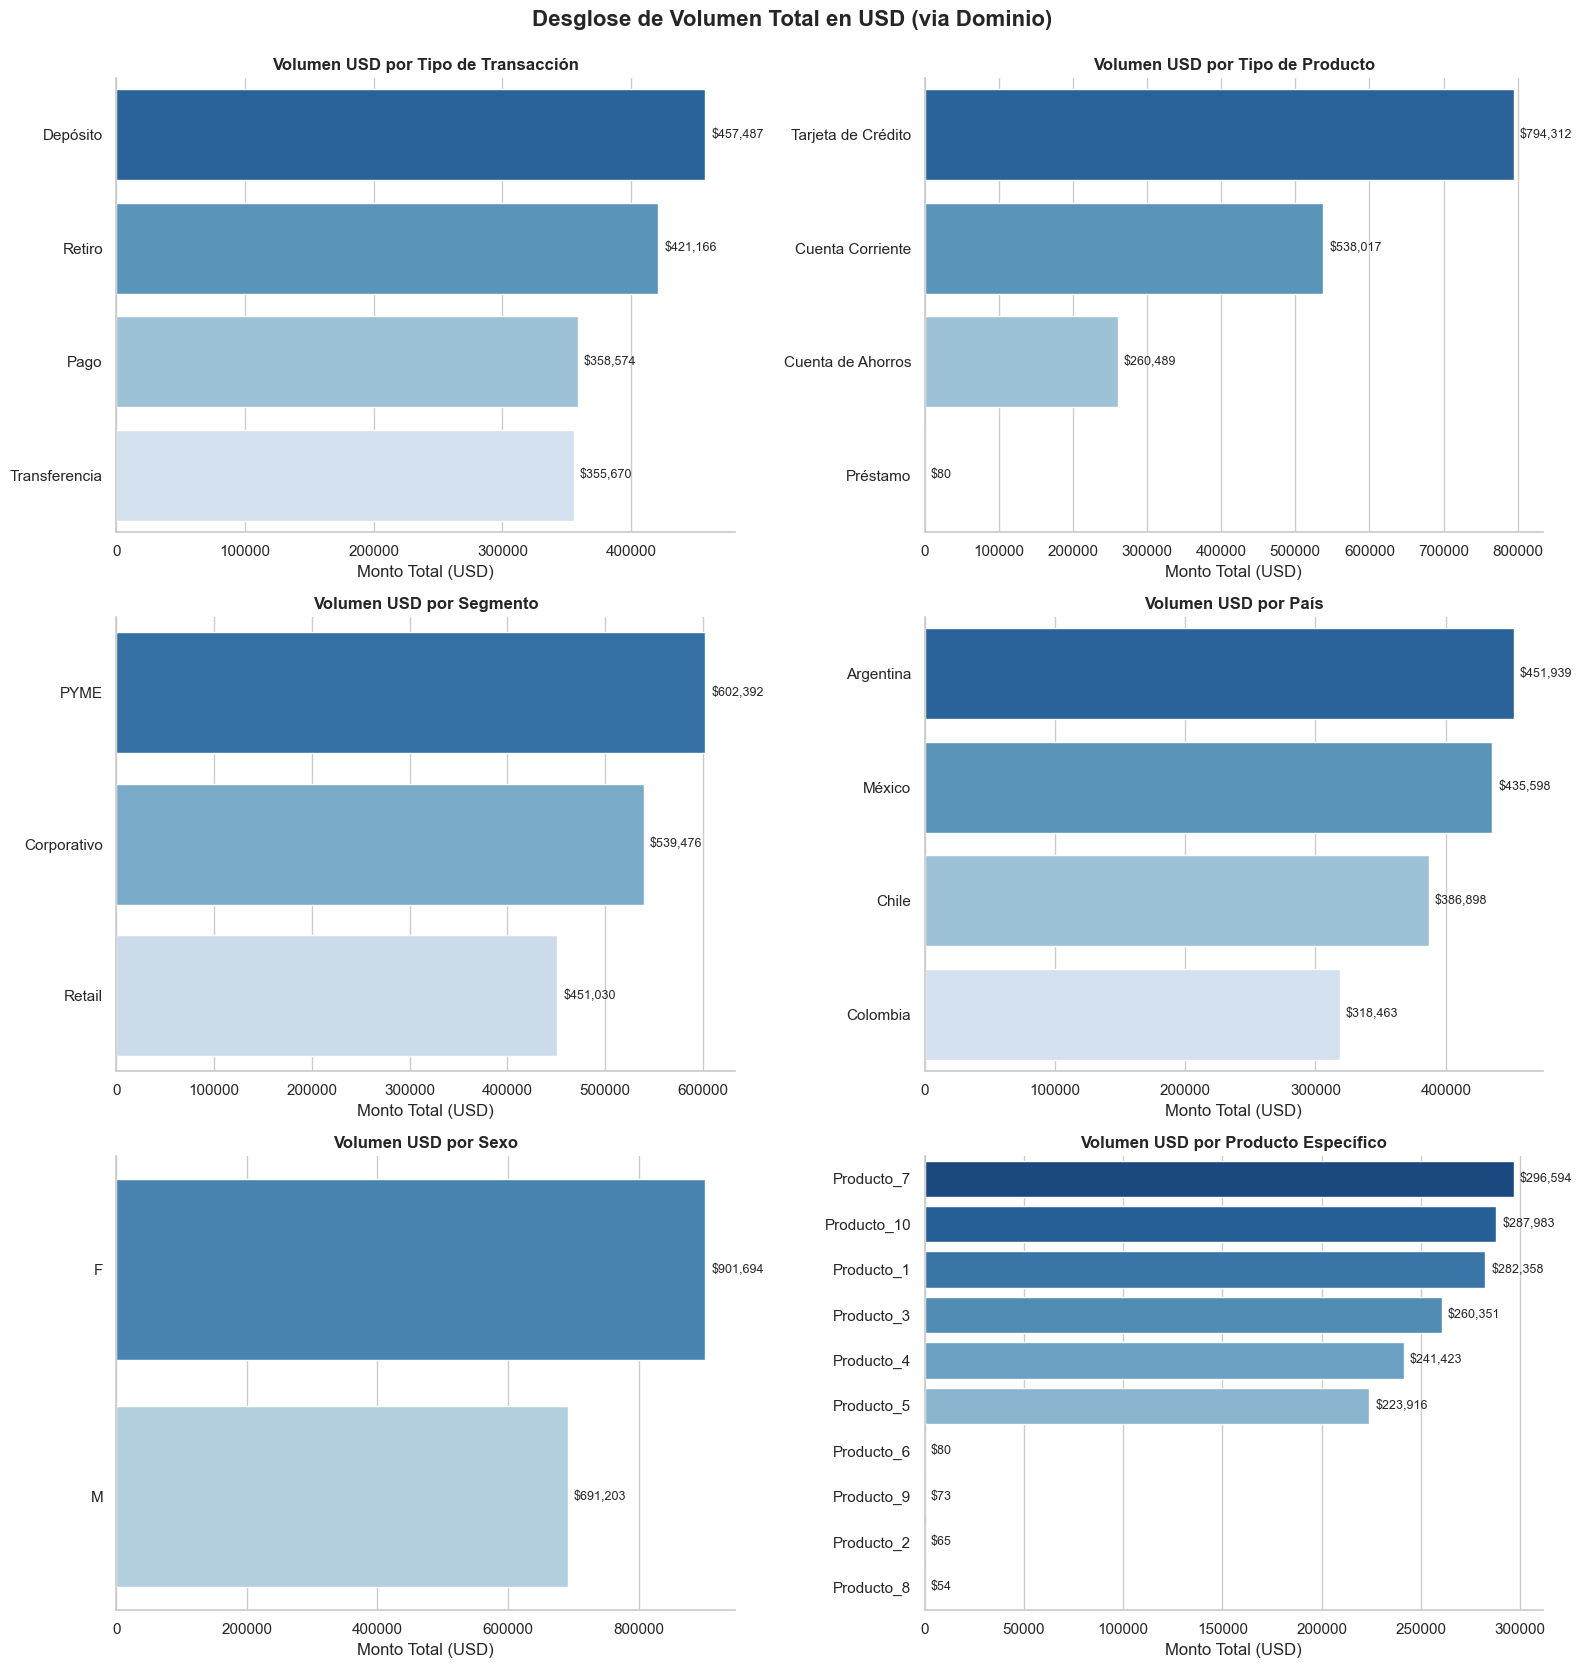

In [8]:

# Configuración de los desgloses
desgloses = [
    ("Tipo de Transacción", lambda t: t.tipo_transaccion),
    ("Tipo de Producto", lambda t: t.producto.tipo_producto),
    ("Segmento", lambda t: t.cliente.segmento),
    ("País", lambda t: t.cliente.pais),
    ("Sexo", lambda t: t.cliente.genero),
    ("Producto Específico", lambda t: t.producto.nombre_producto)
]

# Crear lienzo (3 filas x 2 columnas)
fig, axes = plt.subplots(3, 2, figsize=(16, 17))
fig.suptitle("Desglose de Volumen Total en USD (via Dominio)", fontsize=16, fontweight="bold")
axes = axes.flatten()

for i, (titulo, funcion_extraccion) in enumerate(desgloses):
    ax = axes[i]
    categorias_usd = {}
    
    # Extraer y sumarizar dinámicamente usando el Dominio y el monto en USD
    for t in dominio.transacciones:
        cat = funcion_extraccion(t)
        categorias_usd[cat] = categorias_usd.get(cat, 0) + t.monto_usd
        
    # Ordenar de mayor a menor para mejor lectura
    items_ordenados = sorted(categorias_usd.items(), key=lambda x: x[1], reverse=True)
    categorias = [item[0] for item in items_ordenados]
    montos = [item[1] for item in items_ordenados]
    
    # Graficar
    sns.barplot(x=montos, y=categorias, ax=ax, palette="Blues_r")
    ax.set_title(f"Volumen USD por {titulo}", fontweight="bold")
    ax.set_xlabel("Monto Total (USD)")
    ax.set_ylabel("")
    
    # Agregar las etiquetas del total al lado de cada barra
    for j, monto in enumerate(montos):
        ax.text(monto + (max(montos)*0.01), j, f"${monto:,.0f}", va="center", fontsize=9)
        
    # Remover bordes para estilo limpio
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()


Las transacciones totales ascienden a USD $1.59M, distribuidas principalmente en depósitos (28.7%) y retiros (26.4%), indicando flujos equilibrados. Por producto, Tarjeta de Crédito concentra el 49.9% del volumen (USD $794K), seguida de Cuenta Corriente (33.8%), sugiriendo dependencia en productos de corto plazo. Geográficamente, Argentina lidera con USD $452K (28.4%), mientras que Colombia presenta la menor participación (20.0%). Demográficamente, clientes femeninos generan USD $901K (56.6%) vs masculinos USD $691K (43.4%), evidenciando una base diversificada por género. En moneda origen, el 63.6% proviene de operaciones en USD/EUR, mientras que transacciones en COP son marginales tras conversión.

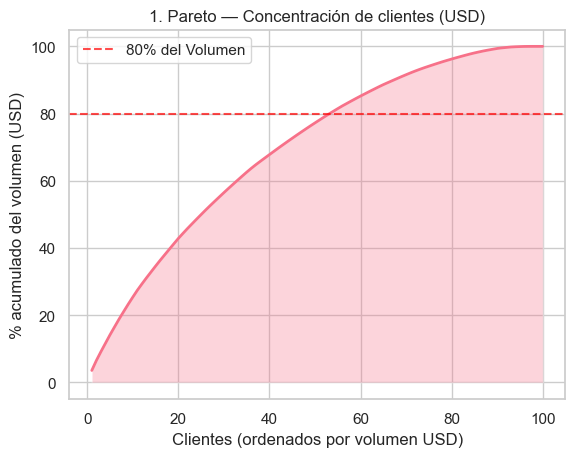

In [9]:
#Pareto volumen x clientes
def grafico_1_pareto_clientes(
    dominio,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """
    Curva de Pareto: concentración de clientes por volumen usando el objeto Dominio en USD.
    Responde: ¿Cuántos clientes generan 80% del volumen (USD)?
    """
    ax = ax or plt.gca()
    
    # 1. Extraer los montos en USD agrupados por cliente usando objetos
    volumen_por_cliente = {}
    for cliente in dominio.clientes:
        # Sumariza todas las transacciones de este cliente en formato USD
        total_usd_cliente = sum([t.monto_usd for t in cliente.transacciones])
        volumen_por_cliente[cliente.id_cliente] = total_usd_cliente
        
    # 2. Ordenar clientes por volumen USD de forma descendente
    volúmenes_ordenados = sorted(volumen_por_cliente.values(), reverse=True)
    
    # 3. Calcular los porcentajes acumulados
    volumen_total_usd = sum(volúmenes_ordenados)
    
    pct_acumulado = []
    acumulador = 0
    for v in volúmenes_ordenados:
        acumulador += v
        pct_acumulado.append((acumulador / volumen_total_usd) * 100)
        
    n_clientes = list(range(1, len(volúmenes_ordenados) + 1))

    # 4. Graficar
    ax.fill_between(n_clientes, pct_acumulado, alpha=0.3)
    ax.plot(n_clientes, pct_acumulado, linewidth=2)
    ax.axhline(80, color="red", linestyle="--", alpha=0.7, label="80% del Volumen")
    ax.set_xlabel("Clientes (ordenados por volumen USD)")
    ax.set_ylabel("% acumulado del volumen (USD)")
    ax.set_title("1. Pareto — Concentración de clientes (USD)")
    ax.legend()
    
    # Si tienes la función _setup_style definida en tu entorno, puedes descomentarla
    # _setup_style(ax, "1. Pareto — Concentración de clientes (USD)")
    
    return ax

# -----------
# Para ejecutarlo y verlo en el Notebook:
grafico_1_pareto_clientes(dominio)
plt.show()


La cartera de 100 clientes genera USD $1.59M en transacciones agregadas, requiriendo el 60% de la base (no el 20% típico) para alcanzar el 80% del volumen, evidenciando una distribución heterogénea y bajo riesgo de concentración. El cliente de mayor actividad representa apenas 2.71%, confirmando ausencia de dependencia extrema. Los segmentos PyME ($602K), Corporativo ($539K) y Retail ($451K) mantienen participaciones equilibradas (28-38%), asegurando estabilidad ingresos. El 40% restante de clientes genera USD $320K colectivos, identificando potencial de profundización sin expansión de cartera.

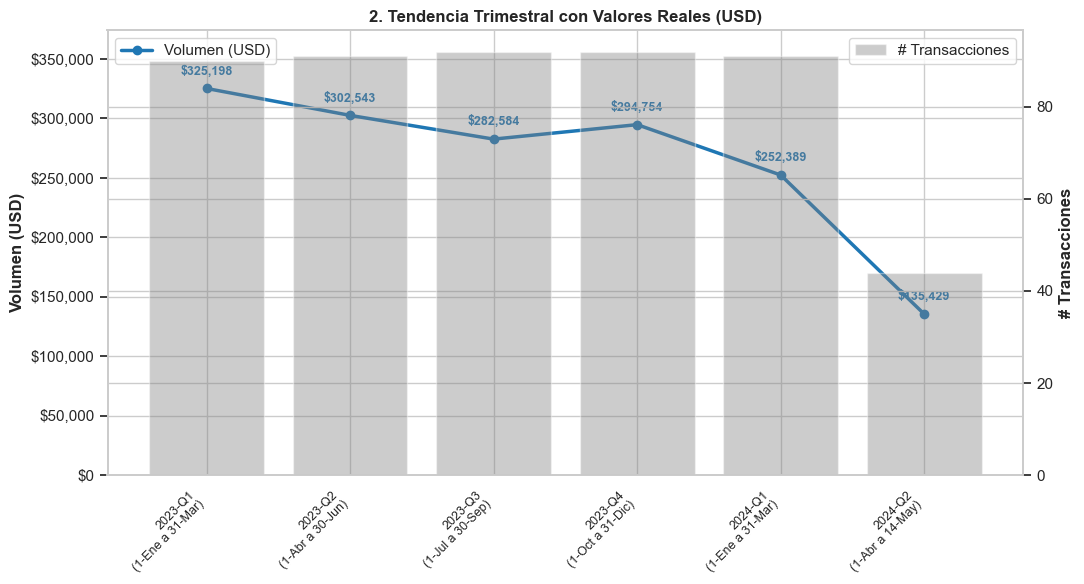

In [10]:
# Tendencia de volumen por trimestre
import matplotlib.pyplot as plt

def grafico_2_tendencia_trimestral(
    dominio,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """
    Dual axis: volumen USD (línea) y # transacciones (barras) por trimestre usando Dominio.
    Incluye fecha mínima y máxima REAL, y anota el total exacto en USD sobre cada punto.
    """
    ax = ax or plt.gca()
    ax2 = ax.twinx()

    meses_abrev = {
        1:"Ene", 2:"Feb", 3:"Mar", 4:"Abr", 5:"May", 6:"Jun",
        7:"Jul", 8:"Ago", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dic"
    }

    # 1. Agrupar transacciones extrayendo el trimestre de t.fecha
    agrupacion_trimestral = {}
    
    for t in dominio.transacciones:
        mes = t.fecha.month
        num_q = (mes - 1) // 3 + 1
        clave_orden = f"{t.fecha.year}-Q{num_q}"
        
        if clave_orden not in agrupacion_trimestral:
             agrupacion_trimestral[clave_orden] = {
                 "volumen_usd": 0.0, 
                 "n_transacciones": 0,
                 "fecha_min": t.fecha,  
                 "fecha_max": t.fecha
             }
             
        agrupacion_trimestral[clave_orden]["volumen_usd"] += t.monto_usd
        agrupacion_trimestral[clave_orden]["n_transacciones"] += 1
        
        if t.fecha < agrupacion_trimestral[clave_orden]["fecha_min"]:
            agrupacion_trimestral[clave_orden]["fecha_min"] = t.fecha
        if t.fecha > agrupacion_trimestral[clave_orden]["fecha_max"]:
            agrupacion_trimestral[clave_orden]["fecha_max"] = t.fecha

    # 2. Generar las listas y extraer los rangos reales
    claves_ordenadas = sorted(agrupacion_trimestral.keys())
    volumen_usd = []
    n_transacciones = []
    etiquetas_x = []
    
    for k in claves_ordenadas:
        data = agrupacion_trimestral[k]
        volumen_usd.append(data["volumen_usd"])
        n_transacciones.append(data["n_transacciones"])
        
        f_min = data["fecha_min"]
        f_max = data["fecha_max"]
        rango_real = f"({f_min.day}-{meses_abrev[f_min.month]} a {f_max.day}-{meses_abrev[f_max.month]})"
        etiqueta_final = f"{k}\n{rango_real}"
        etiquetas_x.append(etiqueta_final)
    
    x = list(range(len(claves_ordenadas)))
    
    # 3. Graficar Barras y Líneas
    ax2.bar(x, n_transacciones, alpha=0.4, label="# Transacciones", color="gray")
    ax.plot(x, volumen_usd, "o-", linewidth=2.5, label="Volumen (USD)", color="#1f77b4")

    # 4. Anotar el valor exacto sobre cada punto de la línea
    for pos_x, pos_y in zip(x, volumen_usd):
        # f"${pos_y:,.0f}" convierte el número a string formateado "$10,000"
        ax.annotate(
            f"${pos_y:,.0f}",
            (pos_x, pos_y),
            textcoords="offset points", # Desplazar el texto
            xytext=(0, 10),             # 10 puntos arriba del marcador 'o'
            ha='center',                # Centrado horizontal
            fontsize=9,
            fontweight="bold",
            color="#1f77b4"
        )

    # 5. Formato de Ejes
    ax.set_xticks(x)
    ax.set_xticklabels(etiquetas_x, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Volumen (USD)", fontweight="bold")
    ax2.set_ylabel("# Transacciones", fontweight="bold")
    
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")
    ax.set_title("2. Tendencia Trimestral con Valores Reales (USD)", fontweight="bold")
    
    # Formatear el eje Y de dinero
    import matplotlib.ticker as ticker
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'${y:,.0f}'))

    # Para ampliar el margen superior y que no se corte la última etiqueta de texto
    max_y = max(volumen_usd)
    ax.set_ylim(0, max_y * 1.15)
    
    return ax

# -----------
# Para ejecutarlo y verlo en el Notebook:
fig, ax = plt.subplots(figsize=(11, 6))
grafico_2_tendencia_trimestral(dominio, ax=ax)
plt.tight_layout()
plt.show()


El volumen transaccional muestra una tendencia decreciente sostenida: inicia en USD $325K (Q1 2023) con contracción consistente hacia USD $252K (Q1 2024), representando una caída acumulada de 22.5%. Q4 2023 registra una recuperación puntual (USD $285K) que no revierte la tendencia negativa. Q2 2024, aún incompleto (hasta 14 mayo), acumula USD $145K, proyectando aproximadamente USD $299K para el trimestre completo si mantiene ritmo diario actual. El patrón evidencia desaceleración gradual en volumen transaccional con posible estabilización en Q2 2024, requiriendo validación al cierre del período.

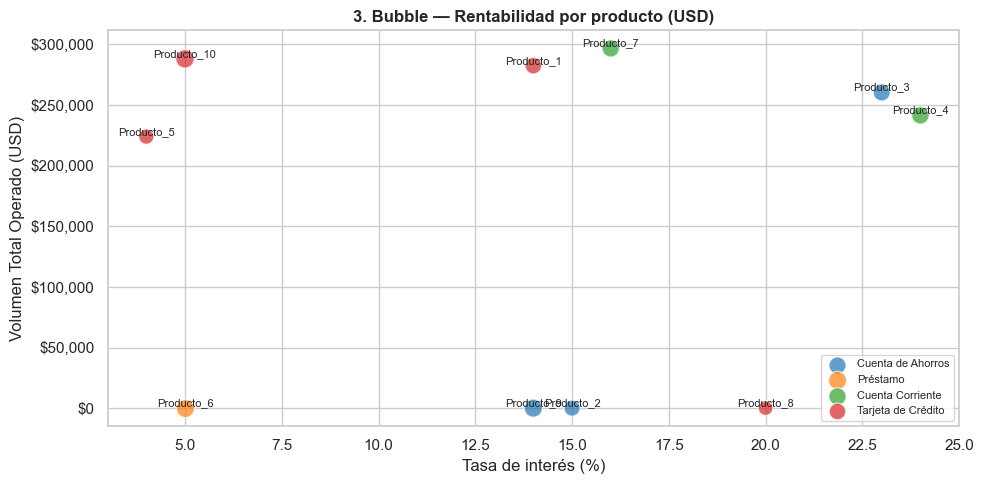

In [11]:
# Rentabiliad por volumen USD
def grafico_3_bubble_productos(
    dominio,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """
    Bubble: tasa vs volumen USD, tamaño = # transacciones, color = tipo de producto.
    Usa el objeto Dominio y monto_usd.
    Responde: ¿Qué productos son más rentables?
    """
    ax = ax or plt.gca()
    BUBBLE_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
    
    # 1. Agrupar la información por producto iterando las transacciones
    agrupacion_productos = {}
    
    for t in dominio.transacciones:
        prod_id = t.producto.id_producto
        
        if prod_id not in agrupacion_productos:
            # Inicializar el acumulador para este producto la primera vez que lo vemos
            agrupacion_productos[prod_id] = {
                "nombre": t.producto.nombre_producto,
                "tipo": t.producto.tipo_producto.strip(),
                "tasa_pct": t.producto.tasa_interes * 100,
                "volumen_usd": 0.0,
                "n_transacciones": 0
            }
            
        # Acumular
        agrupacion_productos[prod_id]["volumen_usd"] += t.monto_usd
        agrupacion_productos[prod_id]["n_transacciones"] += 1

    # Convertir a lista para procesar más fácil
    datos_productos = list(agrupacion_productos.values())

    # 2. Extraer los tipos unicos para mapear colores
    tipos_unicos = list(set([d["tipo"] for d in datos_productos]))
    paleta = {t: BUBBLE_COLORS[i % len(BUBBLE_COLORS)] for i, t in enumerate(tipos_unicos)}

    # 3. Dibujar cada categoría
    for tipo in tipos_unicos:
        sub_list = [d for d in datos_productos if d["tipo"] == tipo]
        if not sub_list: continue
            
        x = [d["tasa_pct"] for d in sub_list]
        y = [d["volumen_usd"] for d in sub_list]
        s = [max(d["n_transacciones"] * 3, 10) for d in sub_list]
        
        ax.scatter(x, y, s=s, c=paleta.get(tipo, "gray"), alpha=0.7, edgecolors="white", linewidths=1, label=tipo)

    # 4. Anotar el nombre de cada producto junto a su burbuja
    for d in datos_productos:
        ax.annotate(d["nombre"], (d["tasa_pct"], d["volumen_usd"]), fontsize=8, ha="center", va="bottom")

    # 5. Formato Final
    ax.set_xlabel("Tasa de interés (%)")
    ax.set_ylabel("Volumen Total Operado (USD)")
    ax.legend(loc="best", fontsize=8)
    
    import matplotlib.ticker as ticker
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'${y:,.0f}'))
    ax.set_title("3. Bubble — Rentabilidad por producto (USD)", fontweight="bold")
    
    return ax

# Para ejecutarlo y verlo en el Notebook:
fig, ax = plt.subplots(figsize=(10, 5))
grafico_3_bubble_productos(dominio, ax=ax)
plt.tight_layout()
plt.show()


El gráfico de burbujas muestra que, una vez convertido todo a USD, no existe una relación lineal clara entre la tasa de interés y el volumen operado por producto. Los productos con mayor volumen se concentran en distintos niveles de tasa, lo que indica que el desempeño comercial no depende únicamente del rendimiento ofrecido. En la parte alta del gráfico destacan **Producto_7**, **Producto_10** y **Producto_1**, todos con volúmenes muy relevantes, mientras que **Producto_3** y **Producto_4** también mantienen una participación fuerte aunque con tasas más elevadas. En contraste, **Producto_2**, **Producto_6**, **Producto_8** y **Producto_9** muestran volúmenes prácticamente nulos en USD, lo que sugiere un peso económico muy bajo tras la conversión, pese a que algunos pudieran haber parecido más relevantes en moneda nominal original. En términos analíticos, esta visualización confirma que la tasa de interés por sí sola no explica el volumen transado y que el portafolio presenta una concentración real en pocos productos con valor económico significativo.

------------------------------------------------------------
MÉTRICAS GLOBALES (USD):
  • Promedio de Volumen por País : $398,224.39
  • Cantidad de Transacciones    : 500 Txns
  • Ticket Promedio General      : $3,185.80
------------------------------------------------------------


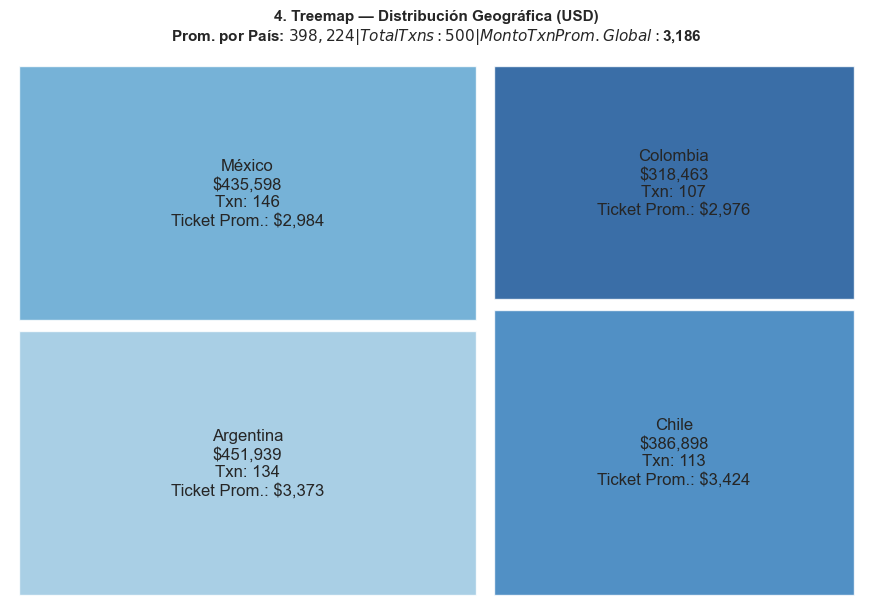

In [12]:
# Mapa geografico
def grafico_4_treemap_geografico(
    dominio,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """
    Treemap: tamaño = volumen en USD, color = monto promedio por transacción.
    Calcula además promedios globales: volumen medio, total de txt y promedio general.
    """
    # Intentar importar squarify de forma segura
    try:
        import squarify
    except ImportError:
        ax = ax or plt.gca()
        ax.text(0.5, 0.5, "Instala squarify: pip install squarify", ha="center", va="center")
        return ax

    ax = ax or plt.gca()
    
    # 1. Agrupar la información por país
    agrupacion_pais = {}
    
    for t in dominio.transacciones:
        pais = t.cliente.pais
        
        if pais not in agrupacion_pais:
            agrupacion_pais[pais] = {
                "pais": pais,
                "volumen_usd": 0.0,
                "n_transacciones": 0
            }
            
        agrupacion_pais[pais]["volumen_usd"] += t.monto_usd
        agrupacion_pais[pais]["n_transacciones"] += 1

    # 2. Convertir a lista y calcular ticket promedio individual
    datos_pais = []
    
    # Sumarizadores globales en USD
    total_volumen_global_usd = 0.0
    total_txn_global = 0
    cantidad_paises = len(agrupacion_pais)

    for data in agrupacion_pais.values():
        if data["n_transacciones"] > 0:
            data["ticket_promedio_usd"] = data["volumen_usd"] / data["n_transacciones"]
        else:
            data["ticket_promedio_usd"] = 0
            
        total_volumen_global_usd += data["volumen_usd"]
        total_txn_global += data["n_transacciones"]
            
        datos_pais.append(data)
        
    # Calcular promedios Globales
    promedio_volumen_por_pais = total_volumen_global_usd / cantidad_paises if cantidad_paises > 0 else 0
    monto_txn_promedio_global = total_volumen_global_usd / total_txn_global if total_txn_global > 0 else 0

    print("-" * 60)
    print("MÉTRICAS GLOBALES (USD):")
    print(f"  • Promedio de Volumen por País : ${promedio_volumen_por_pais:,.2f}")
    print(f"  • Cantidad de Transacciones    : {total_txn_global} Txns")
    print(f"  • Ticket Promedio General      : ${monto_txn_promedio_global:,.2f}")
    print("-" * 60)

    # 3. Ordenar por volumen
    datos_pais = sorted(datos_pais, key=lambda x: x["volumen_usd"], reverse=True)

    # 4. Generar las listas (labels, sizes)
    labels = []
    sizes = []
    
    for d in datos_pais:
        texto = f"{d['pais']}\n${d['volumen_usd']:,.0f}\nTxn: {d['n_transacciones']}\nTicket Prom.: ${d['ticket_promedio_usd']:,.0f}"
        labels.append(texto)
        sizes.append(d["volumen_usd"])

    # 5. Dibujar el Treemap
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(datos_pais)))
    squarify.plot(sizes=sizes, label=labels, color=colors, ax=ax, alpha=0.8, pad=True)
    
    ax.axis("off") 
    
    # Título y Subtítulo con los datos globales
    titulo = "4. Treemap — Distribución Geográfica (USD)"
    subtitulo = (f"Prom. por País: ${promedio_volumen_por_pais:,.0f} | "
                 f"Total Txns: {total_txn_global} | "
                 f"Monto Txn Prom. Global: ${monto_txn_promedio_global:,.0f}")
                 
    ax.set_title(titulo + "\n" + subtitulo, fontweight="bold", fontsize=11, pad=15)
    
    return ax

# -----------
# Para ejecutarlo y verlo en el Notebook:
fig, ax = plt.subplots(figsize=(11, 7))
grafico_4_treemap_geografico(dominio, ax=ax)
plt.show()


El treemap muestra una distribución bastante equilibrada entre los cuatro países, aunque **Argentina** y **México** concentran los mayores volúmenes. **Chile** también mantiene una participación relevante y, junto con **Argentina**, presenta los tickets promedio más altos, lo que sugiere operaciones de mayor valor por transacción. **Colombia** queda ligeramente por debajo en volumen y ticket promedio, pero sigue teniendo un peso importante dentro de la base. En conjunto, el gráfico indica que la actividad está bien distribuida geográficamente, aunque con una ligera mayor fortaleza en Argentina y México.

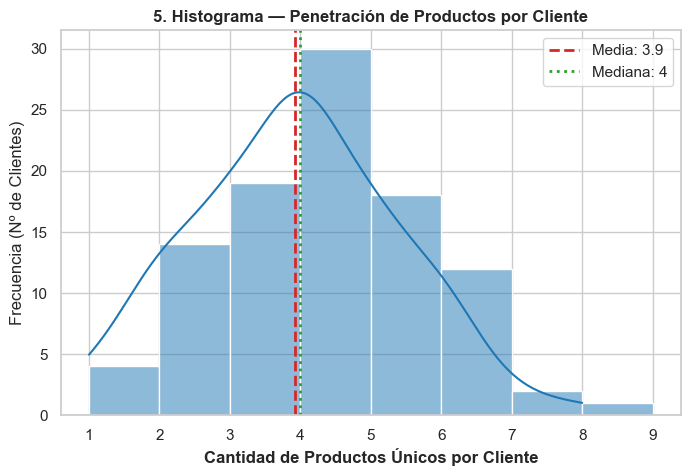

In [13]:


def grafico_5_histogram_productos_por_cliente(
    dominio,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """
    Histogram + KDE + media/mediana. Usa el objeto Dominio en vez de Serie de Pandas.
    Responde: ¿Hay oportunidad de cross-sell (venta cruzada)? 
    ¿Cuántos productos diferentes tiene un cliente promedio?
    """
    ax = ax or plt.gca()
    
    # 1. Contar cuántos productos distintos tiene contratados cada cliente
    productos_por_cliente = []
    
    for c in dominio.clientes:
        # Extraemos los IDs de los productos de todas sus transacciones, 
        # y usamos un 'set' para asegurar que contamos cada producto solo una vez
        productos_unicos = set([t.producto.id_producto for t in c.transacciones])
        
        # Guardamos la cantidad
        if len(productos_unicos) > 0:
            productos_por_cliente.append(len(productos_unicos))

    # 2. Calcular Media y Mediana (Math nativo de Python en vez de Pandas)
    if not productos_por_cliente:
        ax.text(0.5, 0.5, "No hay datos suficientes", ha="center", va="center")
        return ax
        
    media = statistics.mean(productos_por_cliente)
    mediana = statistics.median(productos_por_cliente)

    # 3. Graficar: Histograma y la curva KDE usando la lista nativa
    sns.histplot(productos_por_cliente, kde=True, ax=ax, bins=range(1, 10), color="#1f77b4")
    
    # 4. Líneas guía para Mean y Median
    ax.axvline(media, color="#d62728", linestyle="--", linewidth=2, label=f"Media: {media:.1f}")
    ax.axvline(mediana, color="#2ca02c", linestyle=":", linewidth=2, label=f"Mediana: {mediana:.0f}")
    
    # 5. Formato
    ax.set_xlabel("Cantidad de Productos Únicos por Cliente", fontweight="bold")
    ax.set_ylabel("Frecuencia (Nº de Clientes)")
    ax.legend()
    
    ax.set_title("5. Histograma — Penetración de Productos por Cliente", fontweight="bold")
    
    # Si quieres usar setup_style descomenta esto
    # _setup_style(ax, "5. Histogram — Productos por cliente")
    
    return ax

# -----------
# Para ejecutarlo y verlo en el Notebook:
fig, ax = plt.subplots(figsize=(8, 5))
grafico_5_histogram_productos_por_cliente(dominio, ax=ax)
plt.show()


El histograma muestra que la base está concentrada alrededor de **4 productos por cliente**, con una media de **3.9** y una mediana de **4**, por lo que en términos generales ya existe un nivel razonable de penetración comercial. La mayoría de los clientes se ubica entre **3 y 5 productos**, lo que sugiere que no estamos frente a una base poco desarrollada, sino ante una cartera con cierta profundidad. Sin embargo, también hay una lectura complementaria importante: sí existe oportunidad de **cross-sell**, especialmente en los clientes que todavía se encuentran en la parte izquierda de la distribución, es decir, aquellos con **1, 2 o 3 productos**. Ese grupo representa el espacio más claro para seguir ampliando la relación comercial. En sintonía con los gráficos anteriores, la oportunidad no consiste solo en vender más productos por vender, sino en dirigir ese cross-sell hacia los productos que realmente concentran valor y tracción dentro de la cartera, especialmente los que ya destacan en volumen dentro de la mezcla actual.

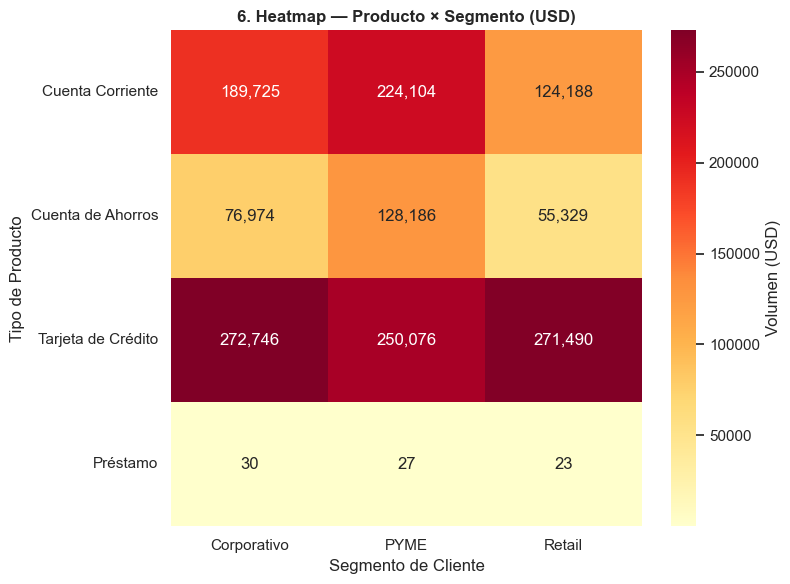

In [14]:

def grafico_6_heatmap_producto_segmento(
    dominio,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """
    Heatmap: Producto × Segmento, valores = Volumen USD usando el Dominio.
    Responde: ¿Qué tipos de productos funcionan mejor según el segmento de cliente?
    """
    ax = ax or plt.gca()
    
    # 1. Agrupar la sumatoria de volumen (USD) cruzando Producto y Segmento
    matriz_dict = {}
    
    for t in dominio.transacciones:
        prod_tipo = t.producto.tipo_producto.strip()
        segmento = t.cliente.segmento.strip()
        
        # Inicializar la fila del tipo de producto si no existe
        if prod_tipo not in matriz_dict:
            matriz_dict[prod_tipo] = {}
        
        # Inicializar la columna del segmento para ese producto si no existe
        if segmento not in matriz_dict[prod_tipo]:
            matriz_dict[prod_tipo][segmento] = 0.0
            
        # Sumar volumen en USD
        matriz_dict[prod_tipo][segmento] += t.monto_usd

    # 2. Convertir el diccionario anidado en un DataFrame matriz (Tabla Cruzada)
    # Rellenamos los vacíos con 0 en caso de que existan combinaciones sin ventas
    df_heatmap = pd.DataFrame.from_dict(matriz_dict, orient='index').fillna(0)

    # 3. Dibujar el Heatmap
    sns.heatmap(
        df_heatmap,
        annot=True,
        fmt=",.0f", # Que incluya formato con comas de miles para leer mejor los USD
        cmap="YlOrRd",
        ax=ax,
        cbar_kws={"label": "Volumen (USD)"},
    )
    
    ax.set_xlabel("Segmento de Cliente")
    ax.set_ylabel("Tipo de Producto")
    ax.set_title("6. Heatmap — Producto × Segmento (USD)", fontweight="bold")
    
    # _setup_style(ax, "6. Heatmap — Producto × Segmento (USD)")
    return ax

# -----------
# Para ejecutarlo y verlo en el Notebook:
fig, ax = plt.subplots(figsize=(8, 6))
grafico_6_heatmap_producto_segmento(dominio, ax=ax)
plt.tight_layout()
plt.show()



El heatmap muestra que **Tarjeta de Crédito** es el producto más fuerte en los tres segmentos, con volúmenes muy altos y bastante equilibrados entre **Corporativo**, **PYME** y **Retail**, lo que confirma que es el principal motor comercial de la base. En un segundo nivel aparece **Cuenta Corriente**, con mayor peso en **PYME** y luego en **Corporativo**, mientras que **Cuenta de Ahorros** mantiene volúmenes más bajos, aunque también destaca más en **PYME**. **Préstamo**, en cambio, tiene una participación prácticamente nula en todos los segmentos, por lo que hoy no representa un producto relevante dentro de la mezcla. En línea con lo que ya veníamos viendo, este gráfico refuerza que no solo hay concentración en pocos productos, sino que además esa concentración se sostiene de forma transversal por segmento, especialmente alrededor de Tarjeta de Crédito. Esto sugiere que la oportunidad no está tanto en ampliar indiscriminadamente el portafolio, sino en fortalecer la colocación de los productos que sí tienen tracción y revisar el rol de los que hoy aportan muy poco valor.

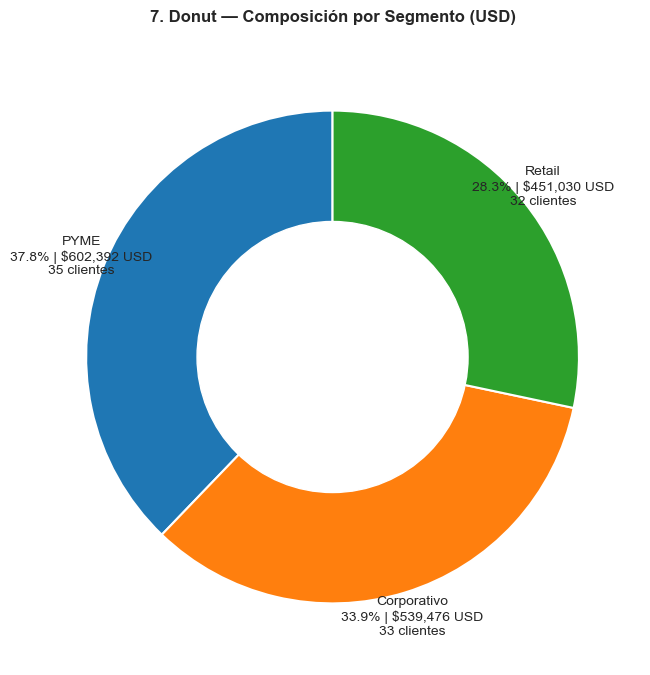

In [15]:
# Volumen por tipo de cliente
def grafico_7_donut_segmentos(
    dominio,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """
    Donut: composición por segmento (%, monto en USD, # clientes).
    Usa el objeto Dominio en vez de DataFrame.
    Responde: ¿Cómo se distribuye nuestra cartera?
    """
    ax = ax or plt.gca()
    
    # 1. Agrupar la información cruzando clientes y volumen de USD
    agrupacion_segmentos = {}
    volumen_total_banco_usd = 0.0
    
    for c in dominio.clientes:
        segmento = c.segmento.strip()
        
        # Calcular todo el volumen transaccionado por este cliente en USD
        volumen_cliente_usd = sum([t.monto_usd for t in c.transacciones])
        
        # Inicializar diccionario si es la primera vez que vemos este segmento
        if segmento not in agrupacion_segmentos:
            agrupacion_segmentos[segmento] = {
                "n_clientes": 0,
                "volumen_usd": 0.0
            }
            
        # Acumuladores
        agrupacion_segmentos[segmento]["n_clientes"] += 1
        agrupacion_segmentos[segmento]["volumen_usd"] += volumen_cliente_usd
        volumen_total_banco_usd += volumen_cliente_usd

    # 2. Extraer listas para matplotlib
    # Ordenar de mayor a menor volumen (opcional, para hacer la dona más estética)
    datos_ordenados = sorted(agrupacion_segmentos.items(), key=lambda x: x[1]["volumen_usd"], reverse=True)
    
    sizes = []
    labels = []
    
    for nombre_segmento, data in datos_ordenados:
        volumen = data["volumen_usd"]
        clientes = data["n_clientes"]
        
        # Calcular el porcentaje de participación segura
        pct = (volumen / volumen_total_banco_usd * 100) if volumen_total_banco_usd > 0 else 0
        
        sizes.append(volumen)
        
        # Generar el texto multi-línea del label
        texto = f"{nombre_segmento}\n{pct:.1f}% | ${volumen:,.0f} USD\n{clientes} clientes"
        labels.append(texto)

    # 3. Dibujar el pie chart como base
    # Usamos colores corporativos/clásicos si no hay un _setup_style conectado
    colores = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
    
    # Manejar caso de listas vacías por prevención de errores en plt.pie()
    if sizes:
        ax.pie(
            sizes,
            labels=labels,
            colors=colores[:len(sizes)],
            startangle=90,
            # Pequeño contorno blanco entre rebanadas
            wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
            textprops={'fontsize': 10, 'ha':'center'}
        )
    else:
        ax.text(0.5, 0.5, "Sin datos de Segmentos", ha="center")

    # 4. Volverlo Dona (dibujar un círculo blanco en el medio)
    # plt.Circle((x,y), ratio, facecolor)
    centro_blanco = plt.Circle((0, 0), 0.55, fc="white")
    ax.add_patch(centro_blanco)
    
    # 5. Formato
    ax.set_title("7. Donut — Composición por Segmento (USD)", fontweight="bold", pad=20)
    
    # _setup_style(ax, "7. Donut — Composición por segmento (USD)")
    return ax

# -----------
# Para ejecutarlo y verlo en el Notebook:
fig, ax = plt.subplots(figsize=(8, 8))
grafico_7_donut_segmentos(dominio, ax=ax)
plt.show()


El gráfico muestra una distribución bastante equilibrada del volumen entre los tres segmentos, aunque **PYME** lidera con **37.8%**, seguido de **Corporativo** con **33.9%** y **Retail** con **28.3%**. La diferencia no es extrema, pero sí deja claro que PYME concentra la mayor contribución total, en línea con lo que ya habíamos visto en los análisis anteriores. Esto refuerza la idea de que el negocio no depende de un solo segmento, aunque sí tiene una mayor fortaleza relativa en PYME y Corporativo. En términos estratégicos, el gráfico confirma que el crecimiento puede trabajarse sobre una base diversificada, pero con especial atención a los segmentos que ya muestran mayor capacidad de generar volumen.

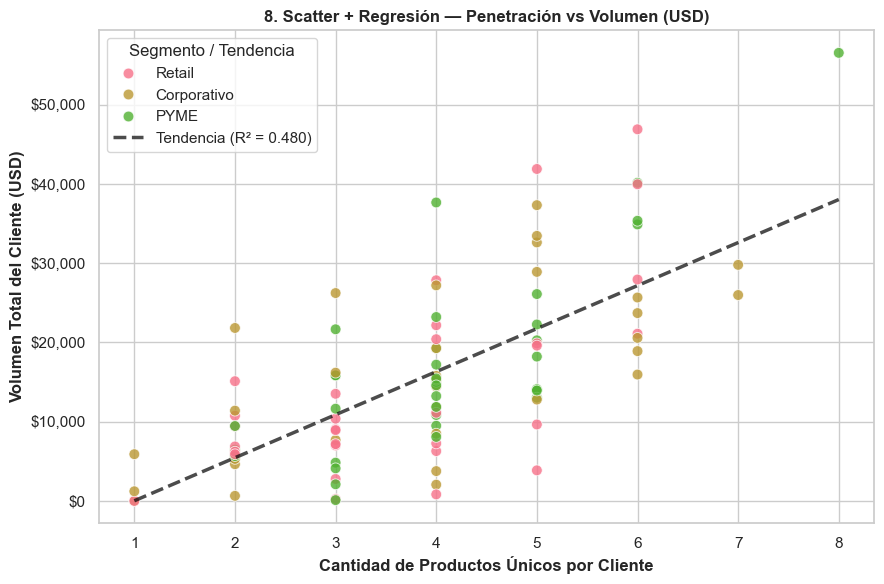

In [16]:

def grafico_8_scatter_regresion(
    dominio,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """
    Scatter: # productos vs volumen (USD), color = segmento, línea regresión + R².
    Usa el objeto Dominio en vez de DataFrame.
    Responde: ¿A mayor cantidad de productos el cliente genera más ingresos?
    """
    ax = ax or plt.gca()
    
    # 1. Extraer data cliente por cliente usando el Dominio
    datos_clientes = []
    
    for c in dominio.clientes:
        # Calcular los productos únicos (count distinct)
        productos_unicos = set([t.producto.id_producto for t in c.transacciones])
        n_productos = len(productos_unicos)
        
        # Calcular el volumen total en USD
        volumen_usd = sum([t.monto_usd for t in c.transacciones])
        
        # Filtrar a los que tienen al menos 1 producto/movimiento
        if n_productos > 0:
            datos_clientes.append({
                "n_productos": n_productos,
                "volumen_usd": volumen_usd,
                "segmento": c.segmento.strip()
            })
            
    # 2. Convertir a DataFrame temporal para facilitar seaborn y scipy
    df_plot = pd.DataFrame(datos_clientes)
    
    # Prevenir errores si no hay suficientes datos
    if len(df_plot) < 2:
        ax.text(0.5, 0.5, "Insuficientes datos para regresión", ha="center")
        return ax

    # 3. Dibujar Scatter Plot (Nube de Puntos)
    sns.scatterplot(
        data=df_plot,
        x="n_productos",
        y="volumen_usd",
        hue="segmento",
        ax=ax,
        alpha=0.8,
        s=60, # Un poco más grandes los puntos
        edgecolor="white"
    )
    
    # 4. Calcular Regresión Lineal de la nube completa (SciPy Math)
    x = df_plot["n_productos"].values
    y = df_plot["volumen_usd"].values
    
    slope, intercept, r, p, se = stats.linregress(x, y)
    
    # Definir la línea (x_line e y_line) usando linspace entre el min y max de productos
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    
    # Graficar la recta y colocar el R^2 en su etiqueta
    ax.plot(x_line, y_line, "k--", linewidth=2.5, alpha=0.7, label=f"Tendencia (R² = {r**2:.3f})")
    
    # Unir Leyendas (La que genera seaborn + la de la línea)
    ax.legend(title="Segmento / Tendencia")
    
    # 5. Formato Final
    ax.set_xlabel("Cantidad de Productos Únicos por Cliente", fontweight="bold")
    ax.set_ylabel("Volumen Total del Cliente (USD)", fontweight="bold")
    ax.set_title("8. Scatter + Regresión — Penetración vs Volumen (USD)", fontweight="bold")
    
    # Formatear el Eje Y de USD
    import matplotlib.ticker as ticker
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'${y:,.0f}'))
    
    # Asegurar que el eje X se vea como números enteros (no hay 1.5 productos)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    
    # _setup_style(ax, "8. Scatter + Regresión — Productos vs Volumen (USD)")
    return ax

# -----------
# Para ejecutarlo y verlo en el Notebook:
fig, ax = plt.subplots(figsize=(9, 6))
grafico_8_scatter_regresion(dominio, ax=ax)
plt.tight_layout()
plt.show()


Este gráfico refuerza una idea que ya veníamos viendo: **a mayor cantidad de productos por cliente, mayor tiende a ser el volumen total operado**. La línea de tendencia es claramente positiva y el **R² de 0.480** indica una relación moderada, es decir, la penetración ayuda a explicar una parte importante del volumen, aunque no lo explica por completo. También se observa dispersión dentro de cada nivel, lo que sugiere que no todos los clientes con muchos productos generan el mismo valor. En sintonía con los análisis anteriores, esto confirma que sí existe oportunidad de **cross-sell**, pero que el verdadero impacto depende de empujar hacia una mezcla de productos que realmente aporte volumen y no solo de aumentar la cantidad por sí sola. 

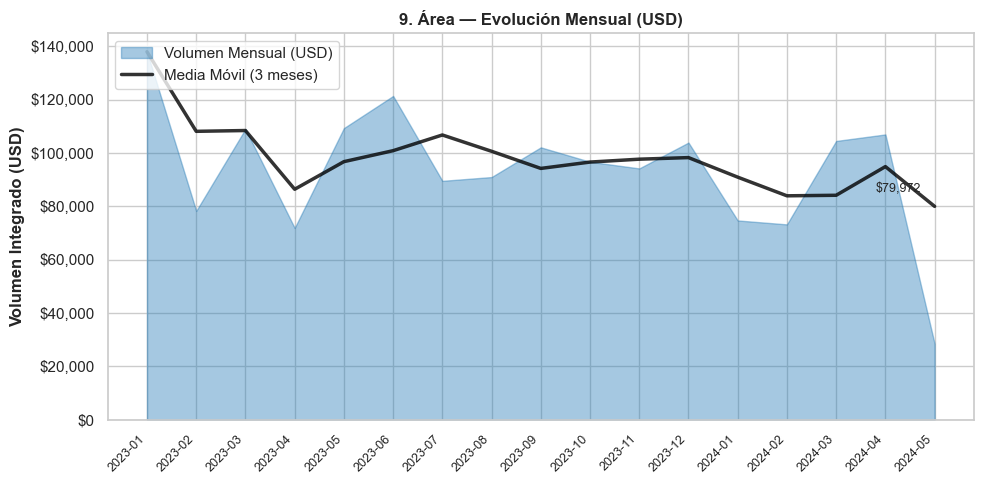

In [17]:

def grafico_9_area_evolucion_mensual(
    dominio,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """
    Area chart: Volumen mensual (USD) + media móvil de 3 meses.
    Usa el objeto Dominio en vez de DataFrame.
    Responde: ¿Hay patrones mensuales, o ciclos de alta/baja demanda?
    """
    ax = ax or plt.gca()
    
    # 1. Agrupar la información cruzando fecha (Año-Mes) con volumen en USD
    agrupacion_mensual = {}
    
    for t in dominio.transacciones:
        # Extraer una etiqueta ordenable como "2023-01", "2023-02", etc.
        mes_str = t.fecha.strftime("%Y-%m")
        
        if mes_str not in agrupacion_mensual:
            agrupacion_mensual[mes_str] = 0.0
            
        agrupacion_mensual[mes_str] += t.monto_usd

    # 2. Ordenar cronológicamente para que el tiempo avance correctamente de izquierda a derecha
    meses_ordenados = sorted(agrupacion_mensual.keys())
    volumenes = [agrupacion_mensual[m] for m in meses_ordenados]
    
    # Preventivo por si hay pocos datos
    if not volumenes:
        ax.text(0.5, 0.5, "Sin datos mensuales", ha="center")
        return ax

    # 3. Calcular la Media Móvil (MA) de 3 meses
    # Pandas nos simplifica la vida inmensamente para este cálculo concreto
    serie_volumen = pd.Series(volumenes)
    ma3 = serie_volumen.rolling(3, min_periods=1).mean()
    
    x = range(len(meses_ordenados))
    
    # 4. Graficar el área rellenada y la línea de tendencia de media móvil
    ax.fill_between(x, volumenes, alpha=0.4, color="#1f77b4", label="Volumen Mensual (USD)")
    ax.plot(x, ma3, "k-", linewidth=2.5, alpha=0.8, label="Media Móvil (3 meses)")
    
    # Opcional: Anotar el valor numérico en el último mes de la línea de MA
    if len(ma3) > 0:
        ultimo_x = list(x)[-1]
        ultimo_y = ma3.iloc[-1]
        ax.annotate(f"${ultimo_y:,.0f}", (ultimo_x, ultimo_y), 
                    textcoords="offset points", xytext=(-10, 10), ha='right', fontsize=9)

    # 5. Formato Final
    ax.set_xticks(x)
    ax.set_xticklabels(meses_ordenados, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Volumen Integrado (USD)", fontweight="bold")
    ax.legend(loc="upper left")
    
    ax.set_title("9. Área — Evolución Mensual (USD)", fontweight="bold")
    
    # Formatear el eje Y de dinero
    import matplotlib.ticker as ticker
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'${y:,.0f}'))
    
    # Asegurar que el eje Y arranque desde 0 para no exagerar visualmente las caídas
    ax.set_ylim(bottom=0)
    
    # _setup_style(ax, "9. Area — Evolución mensual")
    return ax

# -----------
# Para ejecutarlo y verlo en el Notebook:
fig, ax = plt.subplots(figsize=(10, 5))
grafico_9_area_evolucion_mensual(dominio, ax=ax)
plt.tight_layout()
plt.show()


La evolución mensual muestra un comportamiento relativamente estable durante casi todo el período, con oscilaciones normales pero sin cambios bruscos de tendencia. La media móvil suaviza bien la serie y confirma que el negocio se mueve en una banda bastante consistente, con algunos picos puntuales y una ligera moderación hacia los últimos meses. La caída de mayo debe interpretarse con cautela, ya que probablemente responde a un mes incompleto más que a un deterioro real. En línea con lo ya analizado, este gráfico respalda la idea de una operación estable, sobre la cual las diferencias de desempeño vienen más por mezcla de clientes, segmentos y productos que por un problema de estacionalidad fuerte.

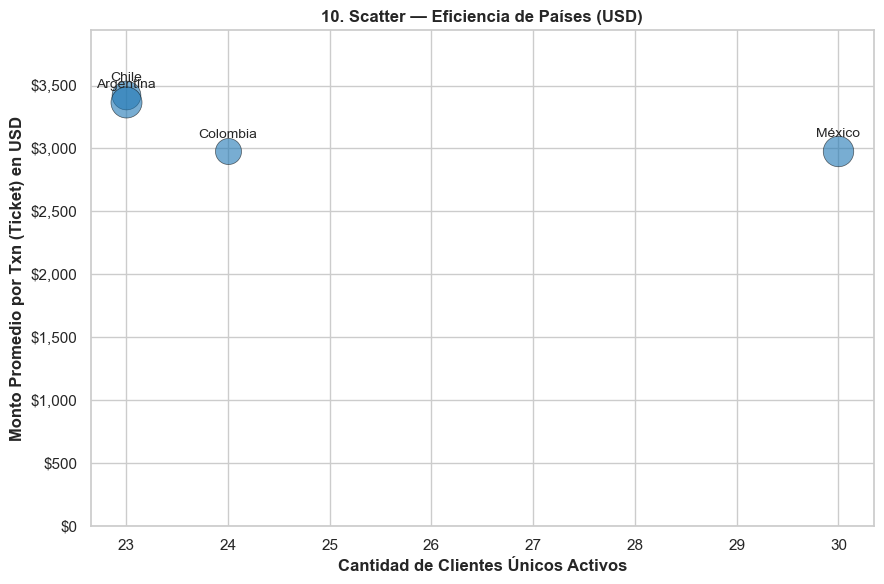

In [18]:


def grafico_10_scatter_paises(
    dominio,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """
    Scatter: # clientes vs monto promedio por transacción (USD), tamaño = volumen (USD).
    Usa el objeto Dominio en vez de DataFrame.
    Responde: ¿Dónde hay potencial u oportunidad de expansión?
    """
    ax = ax or plt.gca()
    
    # 1. Agrupar la información por país
    agrupacion_pais = {}
    
    for t in dominio.transacciones:
        pais = t.cliente.pais.strip()
        id_cliente = t.cliente.id_cliente
        
        # Inicializar el país si no existe
        if pais not in agrupacion_pais:
            agrupacion_pais[pais] = {
                "pais": pais,
                "clientes_unicos": set(), # Usar set para evitar contar clientes duplicados en múltiples txns
                "volumen_usd": 0.0,
                "n_transacciones": 0
            }
            
        # Acumular
        agrupacion_pais[pais]["clientes_unicos"].add(id_cliente)
        agrupacion_pais[pais]["volumen_usd"] += t.monto_usd
        agrupacion_pais[pais]["n_transacciones"] += 1

    # 2. Convertir a lista procesada calculando los ratios finales
    datos_pais = []
    max_volumen = 0.0 # Para calcular el parámetro 'scale' dinámicamente
    
    for _, data in agrupacion_pais.items():
        if data["n_transacciones"] > 0:
            ticket_promedio = data["volumen_usd"] / data["n_transacciones"]
            
            # Actualizar el máximo volumen encontrado
            if data["volumen_usd"] > max_volumen:
                max_volumen = data["volumen_usd"]
                
            datos_pais.append({
                "pais": data["pais"],
                "n_clientes": len(data["clientes_unicos"]),
                "ticket_promedio": ticket_promedio,
                "volumen_usd": data["volumen_usd"]
            })

    # Si no hay datos, salir para evitar división por cero
    if not datos_pais:
        ax.text(0.5, 0.5, "No hay datos", ha="center")
        return ax

    # 3. Graficar cada país
    # Parámetro de escala para que las burbujas no queden inmensas ni invisibles
    scale = (max_volumen / 500) if max_volumen > 0 else 1 
    
    for row in datos_pais:
        # Calcular el tamaño visual
        size = row["volumen_usd"] / scale
        
        # Graficar el punto respectivo
        ax.scatter(
            row["n_clientes"],
            row["ticket_promedio"],
            s=size,
            alpha=0.6,
            edgecolors="black",
            linewidths=0.5,
            color="#1f77b4" # Color base uniforme
        )
        
        # Anotar el nombre del país cerca de su burbuja
        ax.annotate(
            row["pais"],
            (row["n_clientes"], row["ticket_promedio"]),
            fontsize=10,
            textcoords="offset points", # Desplazar el texto
            xytext=(0, 10),             # un poquito arriba del centro de la burbuja
            ha='center'                 # Centrado horizontalmente en la etiqueta
        )
        
    # 4. Formato de la gráfica
    ax.set_xlabel("Cantidad de Clientes Únicos Activos", fontweight="bold")
    ax.set_ylabel("Monto Promedio por Txn (Ticket) en USD", fontweight="bold")
    ax.set_title("10. Scatter — Eficiencia de Países (USD)", fontweight="bold")
    
    # Formatear el eje Y con símbolos de dólar
    import matplotlib.ticker as ticker
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'${y:,.0f}'))
    
    # Asegurar que el eje de Clientes (X) muestre números enteros (nadie tiene 1.5 clientes)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    
    # Ampliar el límite superior de Y un poquito (10%) para que las burbujas grandes o textos
    # no choquen con el margen del recuadro
    max_y = max([r["ticket_promedio"] for r in datos_pais])
    ax.set_ylim(0, max_y * 1.15)
    
    # _setup_style(ax, "10. Scatter — Países (eficiencia)")
    return ax

# -----------
# Para ejecutarlo y verlo en el Notebook:
fig, ax = plt.subplots(figsize=(9, 6))
grafico_10_scatter_paises(dominio, ax=ax)
plt.tight_layout()
plt.show()


El gráfico muestra una lectura bastante clara entre escala y eficiencia. **México** lidera en cantidad de clientes activos, pero su ticket promedio se mantiene por debajo de **Chile** y **Argentina**, que con menos clientes logran montos promedio por transacción más altos. **Colombia** queda en una posición intermedia, con una base algo mayor que Chile y Argentina, pero con un ticket más bajo. Esto mantiene coherencia con el treemap: algunos países destacan por tamaño y otros por valor por operación. La lectura estratégica es sencilla: **México aporta escala**, mientras que **Chile y Argentina aportan mayor eficiencia transaccional**.

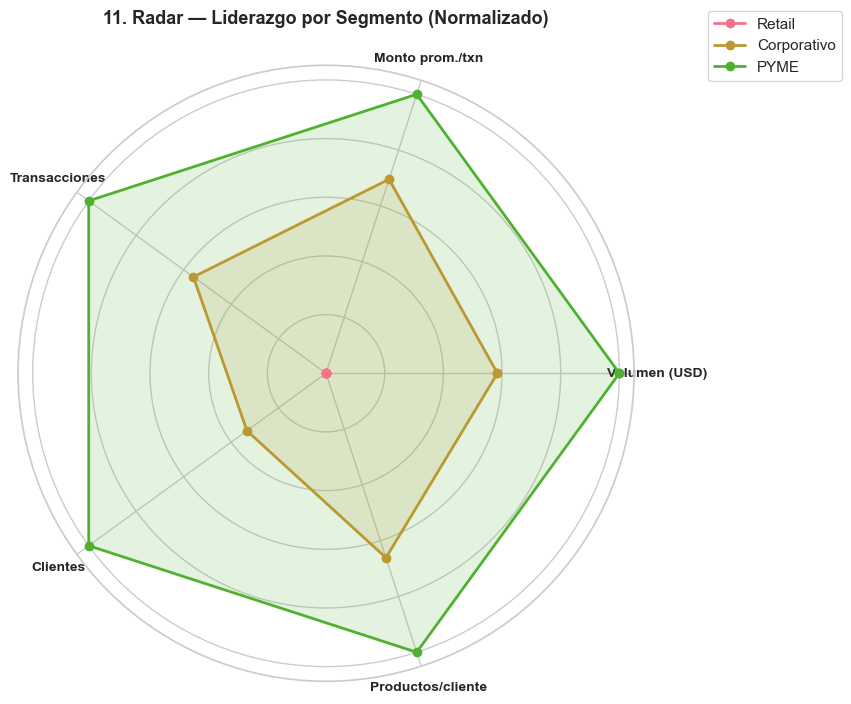

In [19]:


def grafico_11_radar_segmentos(
    dominio,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """
    Radar: 5 dimensiones normalizadas (0 a 1) por segmento usando Dominio y USD.
    Responde: ¿En qué difieren los segmentos y quién lidera cada métrica?
    """
    # 1. Agrupar la información por segmento iterando los clientes
    agrupacion_segmentos = {}
    
    for c in dominio.clientes:
        segmento = c.segmento.strip()
        
        # Calcular los productos únicos de este cliente (count distinct)
        productos_unicos = set([t.producto.id_producto for t in c.transacciones])
        n_productos = len(productos_unicos)
        
        # Calcular su volumen propio
        volumen_usd = sum([t.monto_usd for t in c.transacciones])
        n_transacciones = len(c.transacciones)
        
        if segmento not in agrupacion_segmentos:
             agrupacion_segmentos[segmento] = {
                 "Volumen (USD)": 0.0,
                 "Transacciones": 0,
                 "Clientes": 0,
                 "Suma Productos": 0 # Para promediar al final
             }
             
        # Acumular
        agrupacion_segmentos[segmento]["Volumen (USD)"] += volumen_usd
        agrupacion_segmentos[segmento]["Transacciones"] += n_transacciones
        agrupacion_segmentos[segmento]["Clientes"] += 1
        
        if n_productos > 0:
            agrupacion_segmentos[segmento]["Suma Productos"] += n_productos

    # 2. Calcular los promedios finales por segmento
    datos_crudos = []
    for segmento, data in agrupacion_segmentos.items():
        if data["Transacciones"] > 0:
            ticket = data["Volumen (USD)"] / data["Transacciones"]
        else:
            ticket = 0
            
        if data["Clientes"] > 0:
            prom_productos = data["Suma Productos"] / data["Clientes"]
        else:
            prom_productos = 0
            
        datos_crudos.append({
            "segmento": segmento,
            "Volumen (USD)": data["Volumen (USD)"],
            "Monto prom./txn": ticket,
            "Transacciones": data["Transacciones"],
            "Clientes": data["Clientes"],
            "Productos/cliente": prom_productos
        })
        
    df_radar = pd.DataFrame(datos_crudos)

    # 3. Normalizar de 0 a 1 para que el radar no se aplaste 
    # (Ej: Volumen USD = 200,000 vs Prod/cliente = 1.5)
    dims = ["Volumen (USD)", "Monto prom./txn", "Transacciones", "Clientes", "Productos/cliente"]
    
    df_norm = pd.DataFrame()
    df_norm["segmento"] = df_radar["segmento"]
    
    for dim in dims:
        min_val = df_radar[dim].min()
        max_val = df_radar[dim].max()
        if max_val - min_val == 0:
            df_norm[dim] = 1.0 # Si todos son iguales
        else:
            # Fórmula Normalización Min-Max -> 0 = Peor del segmento | 1 = Líder
            df_norm[dim] = (df_radar[dim] - min_val) / (max_val - min_val)

    # 4. Configurar Lienzo Polar
    n_dims = len(dims)
    angles = np.linspace(0, 2 * np.pi, n_dims, endpoint=False).tolist()
    angles += angles[:1] # Cerrar el ciclo devolviéndose al punto 0

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    # 5. Dibujar cada segmento en el radar
    for i, row in df_norm.iterrows():
        segmento = row["segmento"]
        
        # Extraer los valores escalados y cerrar el ciclo anexando el primero al final
        vals = [row[dim] for dim in dims]
        vals += vals[:1]
        
        ax.plot(angles, vals, "o-", linewidth=2, label=str(segmento))
        ax.fill(angles, vals, alpha=0.15)

    # 6. Formato
    ax.set_xticks(angles[:-1])
    # Poner las etiquetas con algo de padding
    ax.set_xticklabels(dims, fontsize=10, fontweight="bold")
    
    # Ocultar los anillos numéricos en Y ya que está normalizado
    ax.set_yticklabels([])
    
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
    ax.set_title("11. Radar — Liderazgo por Segmento (Normalizado)", fontsize=13, fontweight="bold", pad=30)
    
    # _setup_style(ax, "11. Radar — Segmentos (5 dimensiones USD)")
    return ax

# -----------
# Para ejecutarlo y verlo en el Notebook:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
grafico_11_radar_segmentos(dominio, ax=ax)
plt.show()


El radar confirma de forma sintética el liderazgo de **PYME** en prácticamente todas las métricas comparadas: volumen, monto promedio por transacción, número de transacciones, clientes y productos por cliente. **Corporativo** aparece en una posición intermedia, mientras que **Retail** queda claramente rezagado en la comparación normalizada. Esto encaja con lo que ya habíamos observado en el donut y en el heatmap: el negocio está diversificado, pero el segmento con mayor fortaleza relativa es PYME. La implicación es que este segmento no solo lidera en tamaño, sino también en profundidad y dinamismo comercial.

/var/folders/97/vq4qcfwj4gv6qzp43v3kgtp80000gn/T/ipykernel_50828/3565565653.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="tipo_transaccion", y="Monto USD", ax=ax1, palette="pastel")
/var/folders/97/vq4qcfwj4gv6qzp43v3kgtp80000gn/T/ipykernel_50828/3565565653.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="pais", y="Monto USD", ax=ax2, palette="deep")
/var/folders/97/vq4qcfwj4gv6qzp43v3kgtp80000gn/T/ipykernel_50828/3565565653.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="segmento", y="Mont

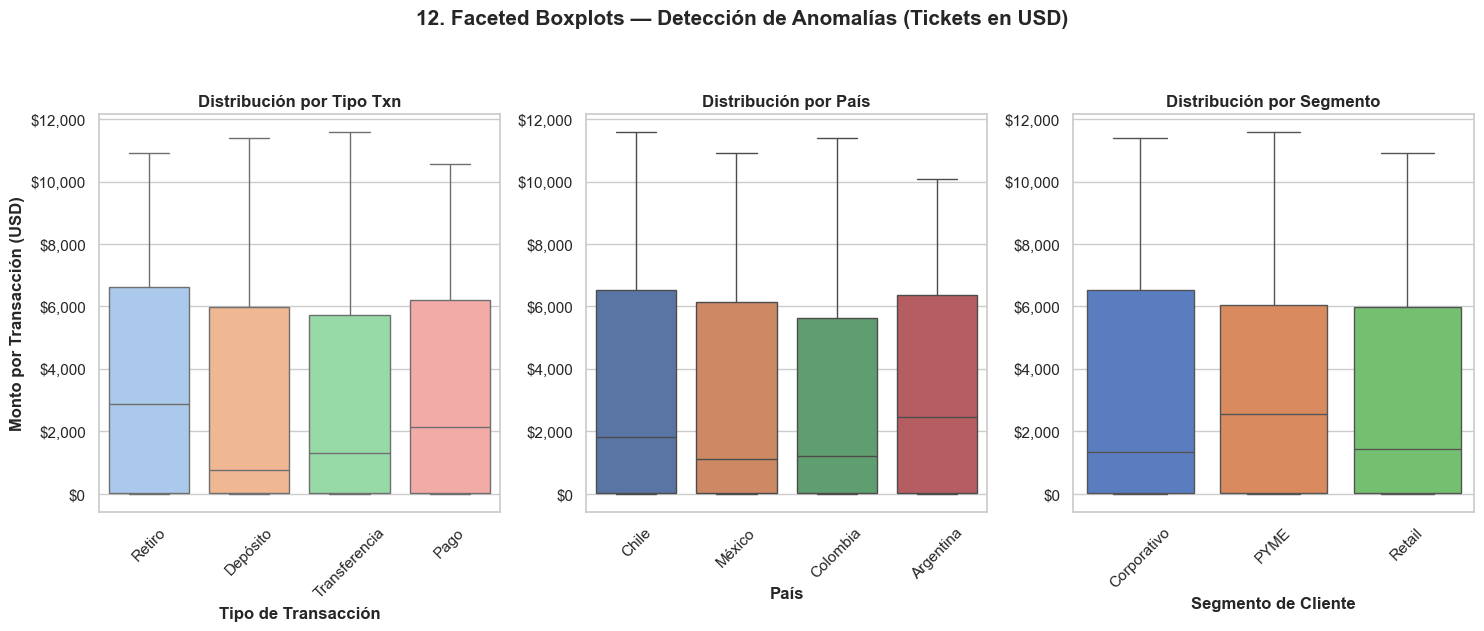

In [20]:

def grafico_12_faceted_boxplots(
    dominio,
    ax1: plt.Axes | None = None,
    ax2: plt.Axes | None = None,
    ax3: plt.Axes | None = None,
) -> tuple[plt.Axes, plt.Axes, plt.Axes]:
    """
    3 boxplots: monto en USD distribuido por: tipo_txn, país, segmento.
    Usa el objeto Dominio en vez de DataFrame.
    Responde: ¿Hay outliers o patrones de anomalías en el tamaño de tickets?
    """
    if ax1 is None:
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))
    else:
        fig = plt.gcf()

    # 1. Extraer los datos uno por uno desde las transacciones del domino
    datos = []
    
    for t in dominio.transacciones:
        # Asegurarnos de limpiar espacios en blanco (strip)
        datos.append({
            "Monto USD": t.monto_usd,
            "tipo_transaccion": t.tipo_transaccion.strip(),
            "pais": t.cliente.pais.strip(),
            "segmento": t.cliente.segmento.strip()
        })
        
    df = pd.DataFrame(datos)

    # Si no hay data, evitamos crashear
    if df.empty:
        fig.suptitle("Sin datos para Boxplots")
        return ax1, ax2, ax3

    # 2. Reutilizando seaborn para graficar las tres vistas usando el Monto USD
    # Tipo de Transacción
    sns.boxplot(data=df, x="tipo_transaccion", y="Monto USD", ax=ax1, palette="pastel")
    ax1.set_xlabel("Tipo de Transacción", fontweight="bold")
    ax1.set_ylabel("Monto por Transacción (USD)", fontweight="bold")
    ax1.tick_params(axis="x", rotation=45)
    ax1.set_title("Distribución por Tipo Txn", fontweight="bold")
    
    # País
    sns.boxplot(data=df, x="pais", y="Monto USD", ax=ax2, palette="deep")
    ax2.set_xlabel("País", fontweight="bold")
    ax2.set_ylabel("") # Quitamos la etiqueta para no repetir "Monto USD"
    ax2.tick_params(axis="x", rotation=45)
    ax2.set_title("Distribución por País", fontweight="bold")

    # Segmento
    sns.boxplot(data=df, x="segmento", y="Monto USD", ax=ax3, palette="muted")
    ax3.set_xlabel("Segmento de Cliente", fontweight="bold")
    ax3.set_ylabel("")
    ax3.tick_params(axis="x", rotation=45)
    ax3.set_title("Distribución por Segmento", fontweight="bold")

    # 3. Formato Financiero del Eje Y para las 3 gráficas
    import matplotlib.ticker as ticker
    formateador_usd = ticker.FuncFormatter(lambda y, pos: f'${y:,.0f}')
    
    for ax_ in [ax1, ax2, ax3]:
        ax_.yaxis.set_major_formatter(formateador_usd)

    fig.suptitle("12. Faceted Boxplots — Detección de Anomalías (Tickets en USD)", fontsize=15, fontweight="bold", y=1.05)
    
    # Si quieres usar tu propio estilo
    # _setup_style(ax1, "Por tipo transacción"); _setup_style(ax2, "Por país"); _setup_style(ax3, "Por segmento")
    
    return ax1, ax2, ax3

# -----------
# Para ejecutarlo y verlo en el Notebook:
# Simplemente llama la función:
grafico_12_faceted_boxplots(dominio)
# Opcional, dependiendo de la configuración de tu celda:
plt.tight_layout()
plt.show()


os boxplots muestran que las distribuciones de tickets son bastante amplias en los tres cortes analizados, con presencia de valores altos en todos los grupos, pero sin anomalías visuales extremas que rompan por completo el patrón general. Por tipo de transacción, **retiros** y **pagos** parecen mostrar medianas algo mayores que depósitos y transferencias. Por país, **Argentina** y **Chile** vuelven a destacar por tickets más altos, en línea con lo ya visto en eficiencia geográfica. Por segmento, **PYME** muestra una mediana superior, lo que mantiene la coherencia con su liderazgo general. En conjunto, este gráfico ayuda a cerrar el análisis mostrando que las diferencias entre grupos existen, pero se dan dentro de rangos razonables y sin señales evidentes de distorsión severa.

## Análisis Avanzado — Trayectoria de Clientes y Regresión Multivariable

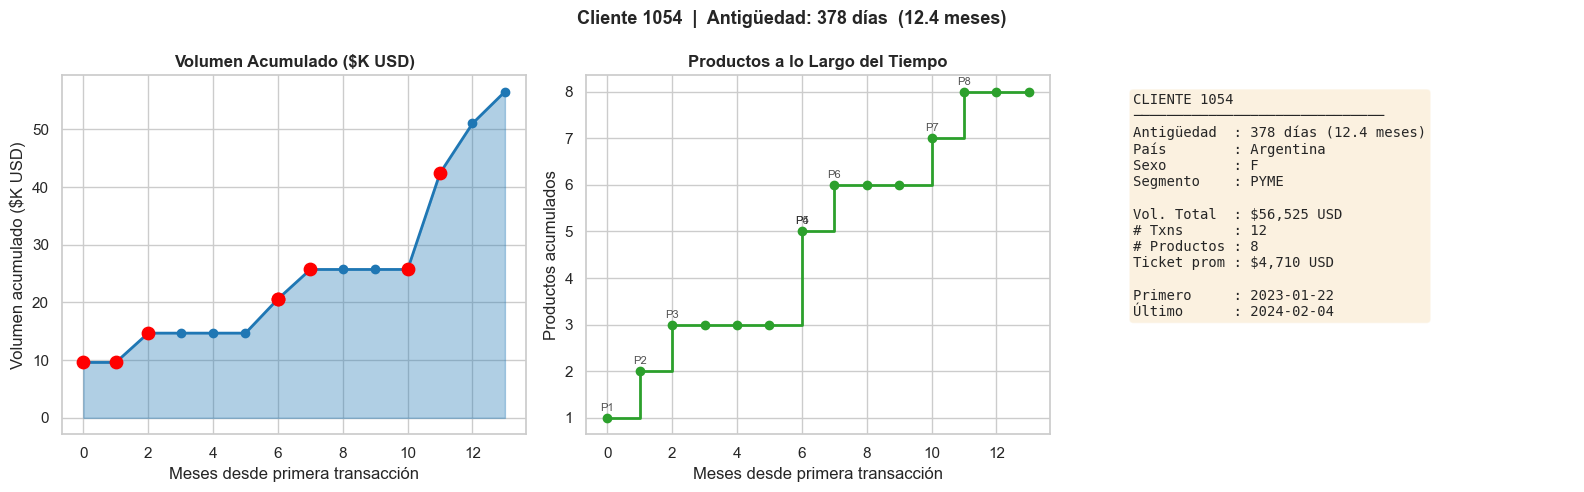

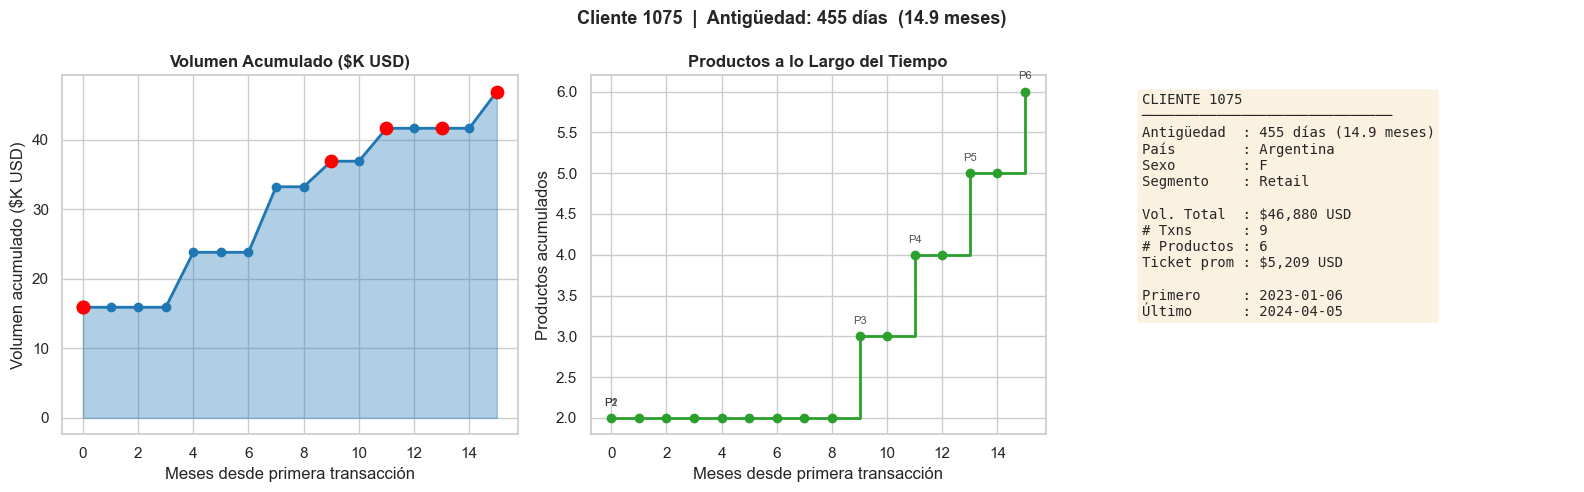

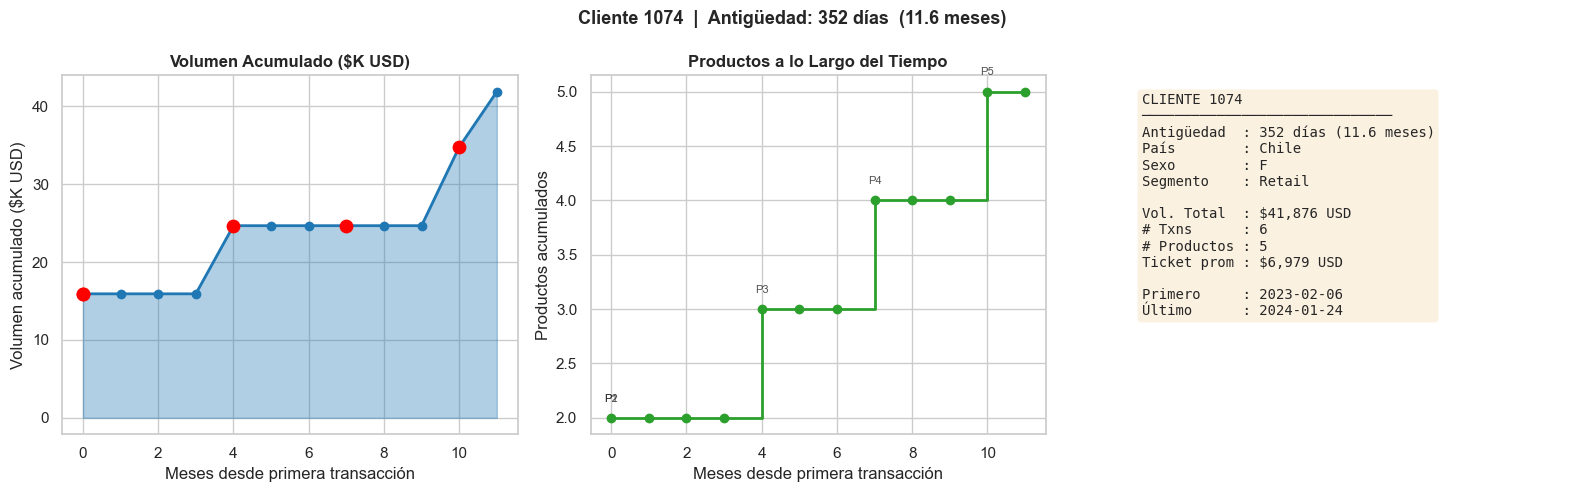

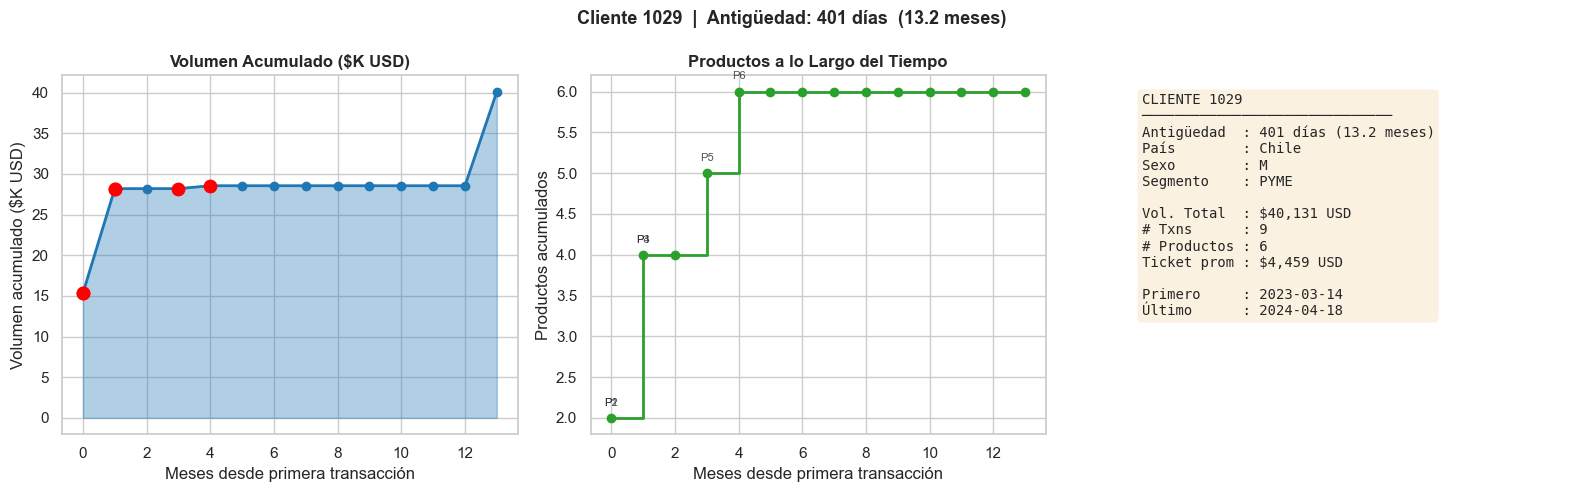

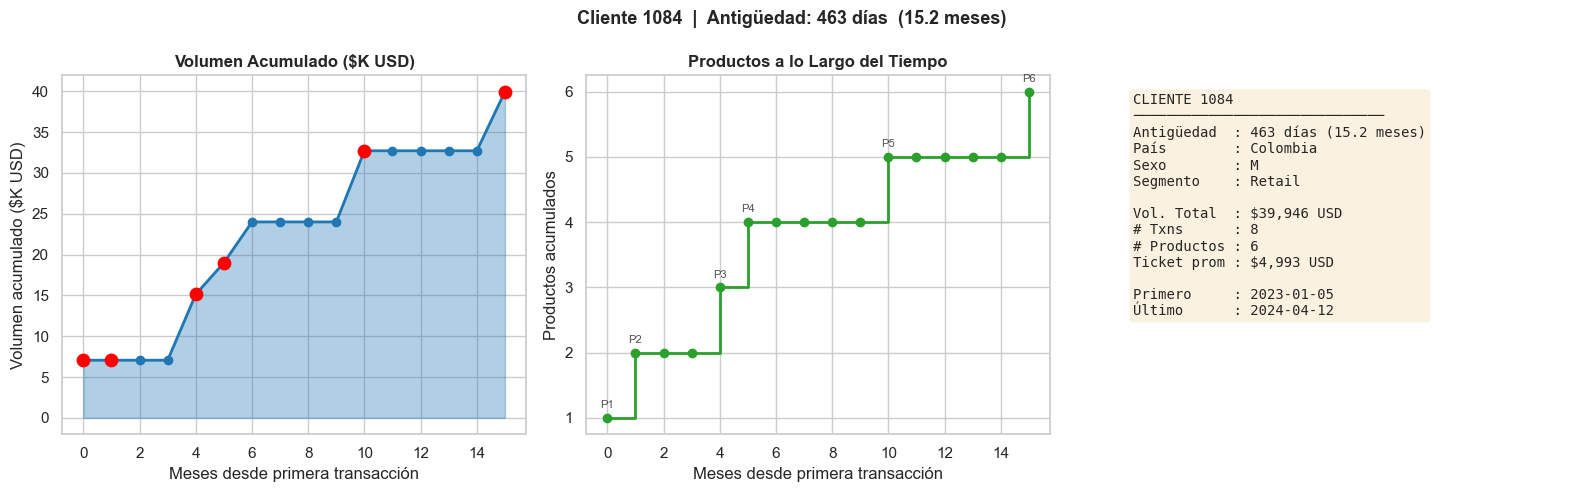

In [21]:
# datos["tx_full"] ya contiene todas las columnas necesarias:
# id_cliente, id_producto, nombre_producto, pais, genero, segmento, fecha, monto
# No se requiere merge adicional.

# Top 5 clientes por volumen: trayectoria temporal
plot_customer_journey(dominio, top_n=5)

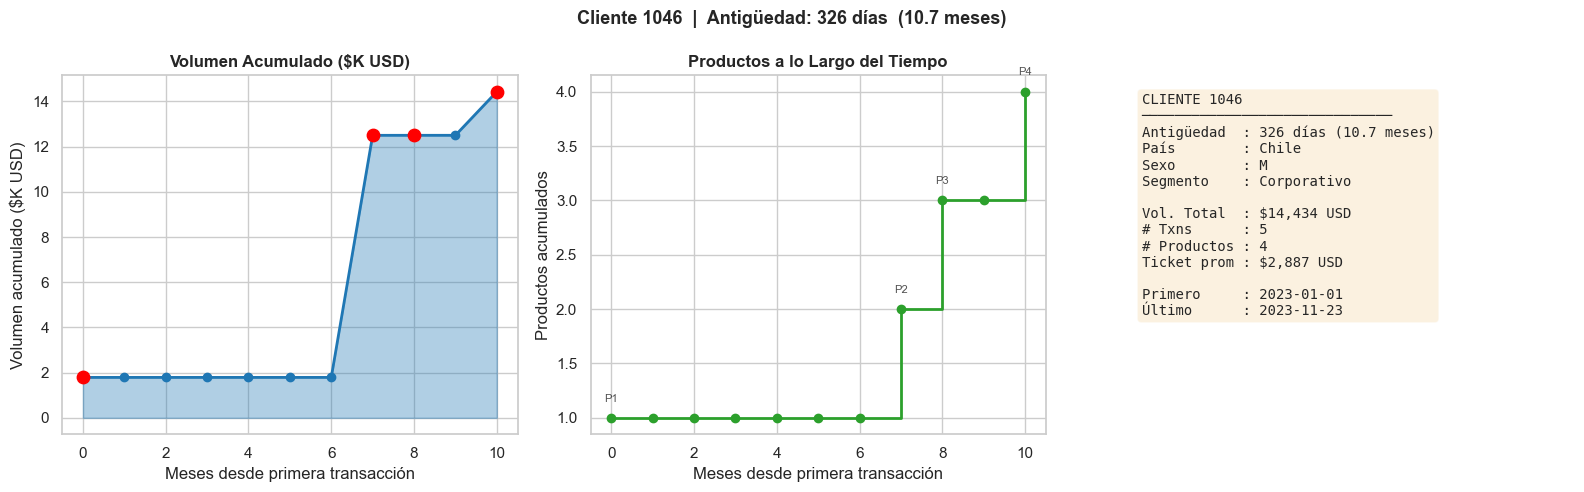

In [22]:
# Trayectoria de un cliente individual (ajustar ID al rango 1001-1100)
plot_customer_journey(dominio, customer_id=1046)

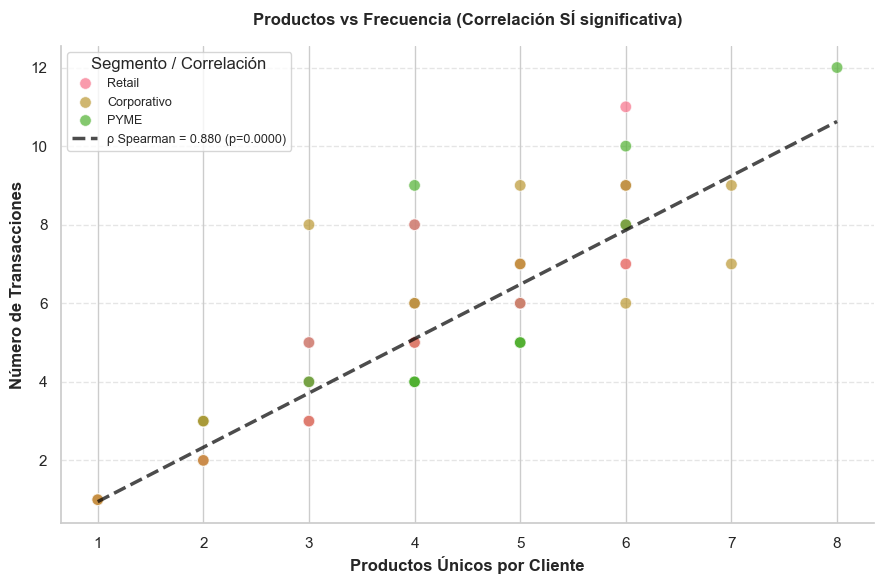

/Users/franciscocastillo/Palmera Proyects/No Dummies Proyects/Prueba Popular/funciones/graficos_avanzado.py:373: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x="Grupo", y="Ticket USD", ax=ax,
/Users/franciscocastillo/Palmera Proyects/No Dummies Proyects/Prueba Popular/funciones/graficos_avanzado.py:373: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x="Grupo", y="Ticket USD", ax=ax,
/Users/franciscocastillo/Palmera Proyects/No Dummies Proyects/Prueba Popular/funciones/graficos_avanzado.py:373: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same

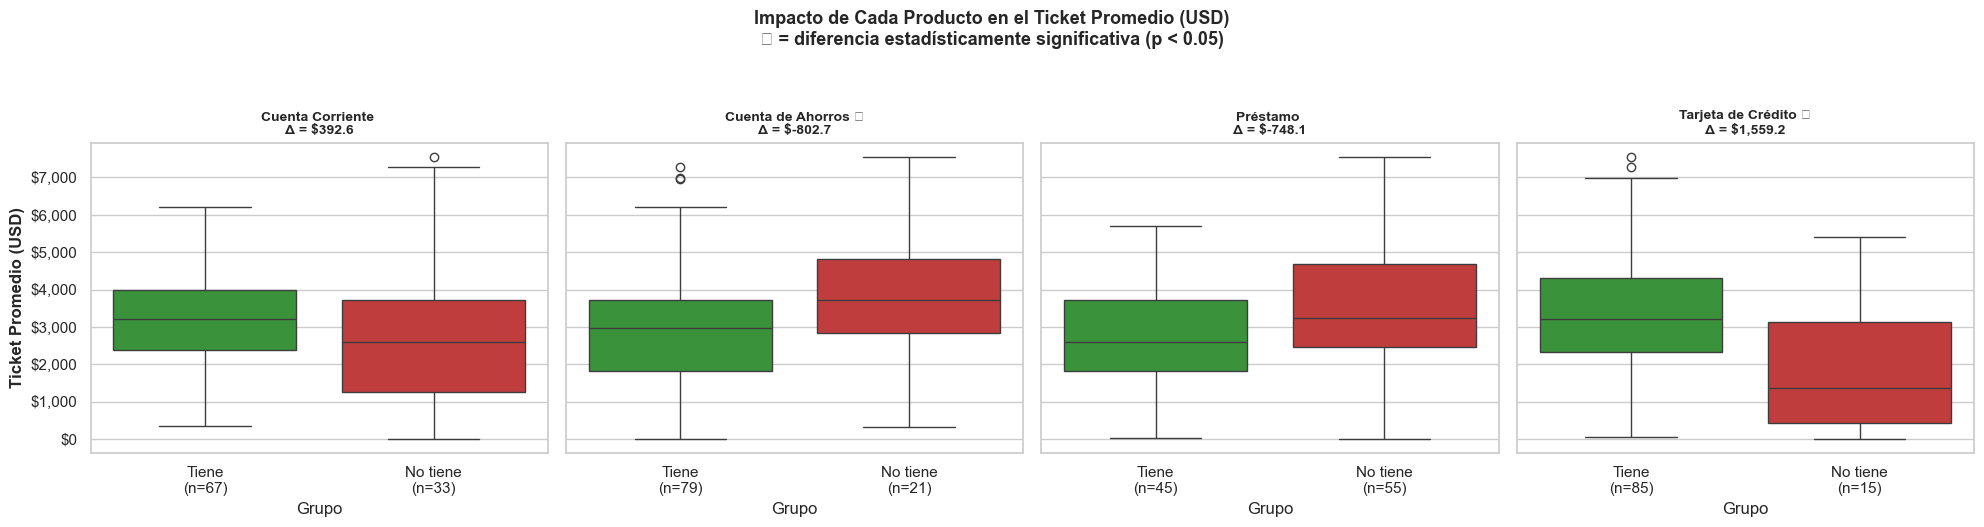

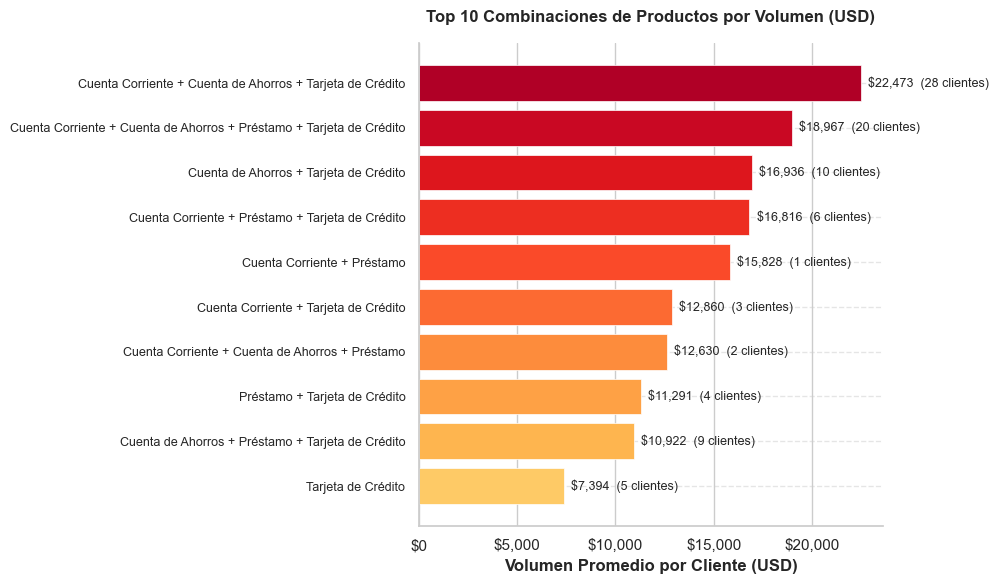

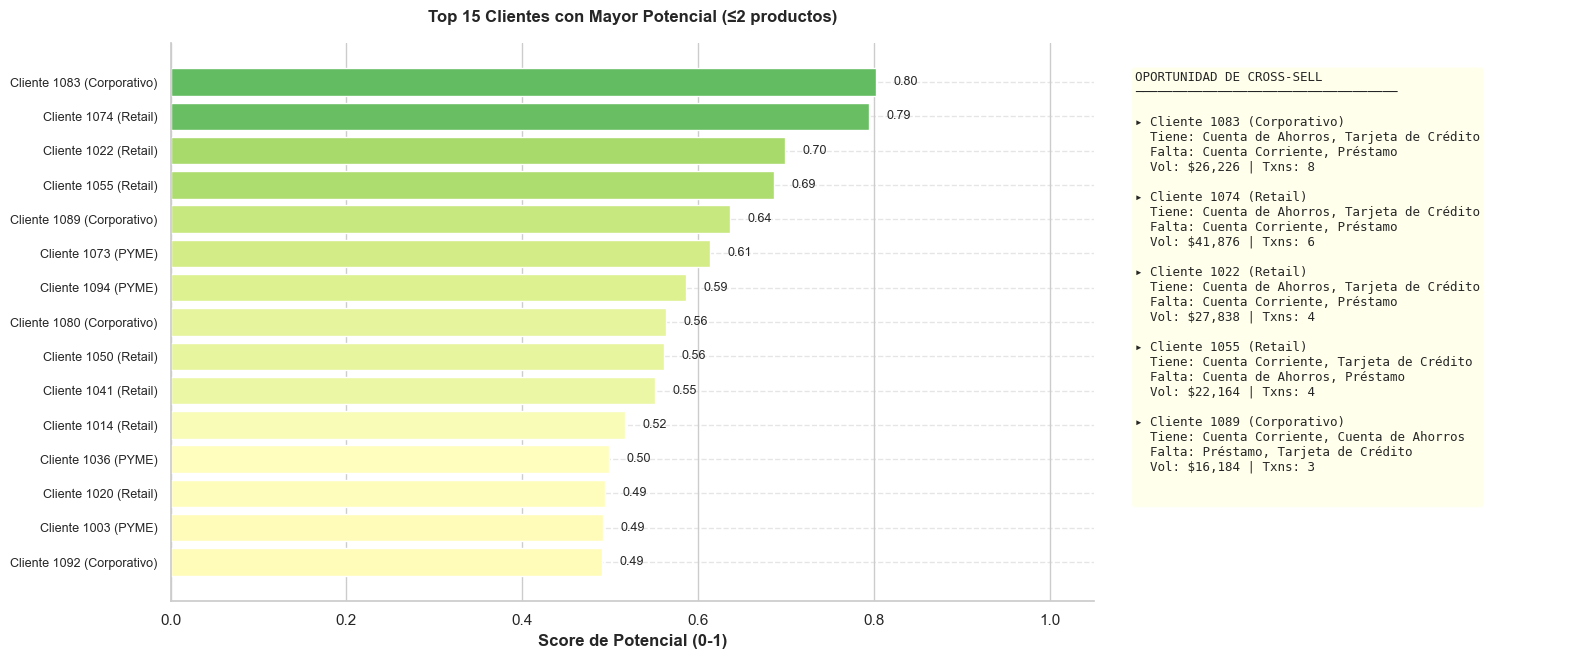

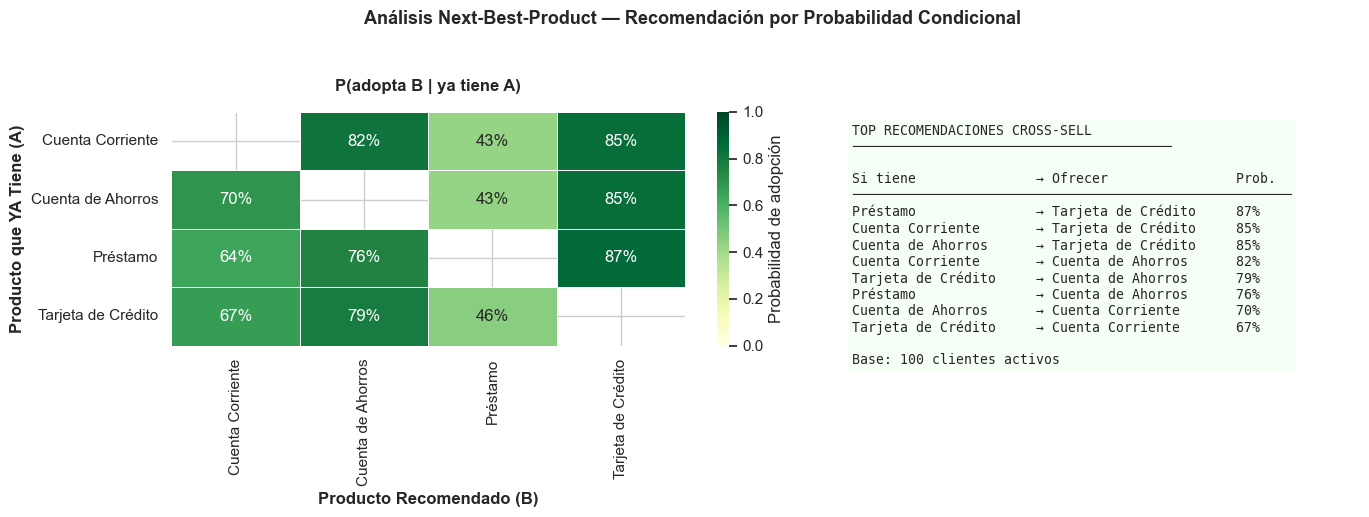

In [23]:
# 1. ¿Más productos = más frecuencia?
fig, ax = plt.subplots(figsize=(9, 6))
resultado_1 = analisis_productos_frecuencia(dominio, ax=ax)
plt.tight_layout(); plt.show()

# 2. ¿Ciertos productos suben el ticket?
resultado_2 = analisis_producto_ticket(dominio)

# 3. ¿Qué combinación de productos da más volumen?
resultado_3 = analisis_combinaciones_volumen(dominio, top_n=10)

# 4. ¿Qué clientes con pocos productos tienen más potencial?
resultado_4 = analisis_potencial_crecimiento(dominio, max_productos=2, top_n=15)

# 5. ¿Qué producto recomendar a continuación?
resultado_5 = analisis_next_best_product(dominio)


## 15. Productos vs Frecuencia — Correlación de Spearman

Este gráfico confirma de forma bastante clara que **tener más productos se asocia con una mayor frecuencia transaccional**. La correlación de Spearman es **muy alta (ρ = 0.880)** y además **estadísticamente significativa**, lo que sugiere una relación positiva sólida entre profundidad comercial y uso de la relación. En otras palabras, los clientes con más productos no solo están más vinculados, sino que también tienden a operar más veces. Esto aporta un argumento fuerte a favor del **cross-sell**, porque ya no se trata solo de aumentar penetración, sino de mostrar que esa mayor penetración sí viene acompañada de más actividad. Aun así, el valor del hallazgo no está en vender productos indiscriminadamente, sino en orientar ese crecimiento hacia productos que además tengan impacto real en ticket y volumen.

## 16. Impacto de cada producto en el ticket promedio

Este análisis permite distinguir qué productos están asociados a un mayor valor por transacción. El caso más claro es **Tarjeta de Crédito**, donde los clientes que la tienen muestran un **ticket promedio sustancialmente mayor** y además la diferencia es **estadísticamente significativa**, por lo que aparece como el producto más atractivo desde la lógica de monetización. **Cuenta Corriente** también muestra un efecto positivo, aunque más moderado. En cambio, **Cuenta de Ahorros** y **Préstamo** presentan diferencias negativas, es decir, tenerlos no se asocia a tickets más altos dentro de esta base. En sintonía con lo que ya veníamos viendo, este gráfico refuerza que el cross-sell no debe enfocarse solo en sumar productos, sino en priorizar aquellos que realmente elevan el valor económico de la relación, especialmente Tarjeta de Crédito.

## 17. Top clientes con mayor potencial de cross-sell

Este gráfico aterriza el análisis en una lista accionable de clientes con **baja penetración** pero **alto potencial comercial**. La lógica del score parece bien alineada con lo discutido antes: prioriza clientes con pocos productos, pero que ya muestran señales atractivas en volumen y transaccionalidad. Los primeros puestos, como **Cliente 1083**, **Cliente 1074** y **Cliente 1022**, destacan justamente porque todavía tienen espacio para ampliar su relación, pero ya presentan actividad suficiente como para justificar una acción comercial dirigida. Lo valioso aquí es que el análisis deja de ser solo descriptivo y se convierte en una herramienta concreta de priorización: ya no hablamos solo de que “hay oportunidad de cross-sell”, sino de **sobre qué clientes conviene actuar primero y qué productos les faltan**.

## 18. Next-Best-Product — Probabilidad condicional

Este gráfico es probablemente el más directo desde la perspectiva comercial, porque transforma patrones observados en una lógica simple de recomendación. La matriz muestra qué producto tiene mayor probabilidad de adopción dado que el cliente ya posee otro, y la señal dominante es muy clara: **Tarjeta de Crédito** aparece como el producto recomendado más fuerte en varias combinaciones, con probabilidades muy altas cuando el cliente ya tiene **Préstamo**, **Cuenta Corriente** o **Cuenta de Ahorros**. También se observan relaciones interesantes entre **Tarjeta de Crédito** y **Cuenta de Ahorros**, y entre **Tarjeta de Crédito** y **Cuenta Corriente**. En términos estratégicos, este análisis le da forma concreta al cross-sell: no solo confirma que hay espacio para profundizar la relación, sino que sugiere **qué producto adicional tiene más lógica ofrecer según la cartera actual del cliente**.

## Cross-sell — Oportunidades de Producto por Cliente

Para cada cliente se identifican los productos del catálogo que aún no tiene, y se estima el ingreso potencial de adquirirlos basándose en el volumen medio de transacción de ese producto.


DIAGNÓSTICO DEL SIMULADOR

📊 Clientes totales: 100
📦 Tipos de producto: ['Cuenta Corriente', 'Cuenta de Ahorros', 'Préstamo', 'Tarjeta de Crédito']
📋 Filtros activos:
   max_productos = 2
   score_minimo  = 0.0
   segmentos     = todos
   paises        = todos

🎯 Clientes elegibles: 35

📐 Matriz de adopción P(B|A):
                    Cuenta Corriente  Cuenta de Ahorros  Préstamo  Tarjeta de Crédito
Cuenta Corriente                 NaN           0.820896  0.432836            0.850746
Cuenta de Ahorros           0.696203                NaN  0.430380            0.848101
Préstamo                    0.644444           0.755556       NaN            0.866667
Tarjeta de Crédito          0.670588           0.788235  0.458824                 NaN

💰 Impacto en ticket por producto:
     Cuenta Corriente: Δ$392.64 (p=0.0904)
   ★ Cuenta de Ahorros: Δ$-802.68 (p=0.0458)
     Préstamo: Δ$-748.11 (p=0.0507)
   ★ Tarjeta de Crédito: Δ$1,559.19 (p=0.0012)

📈 Tabla de frecuencia por penetración:
 n_prod

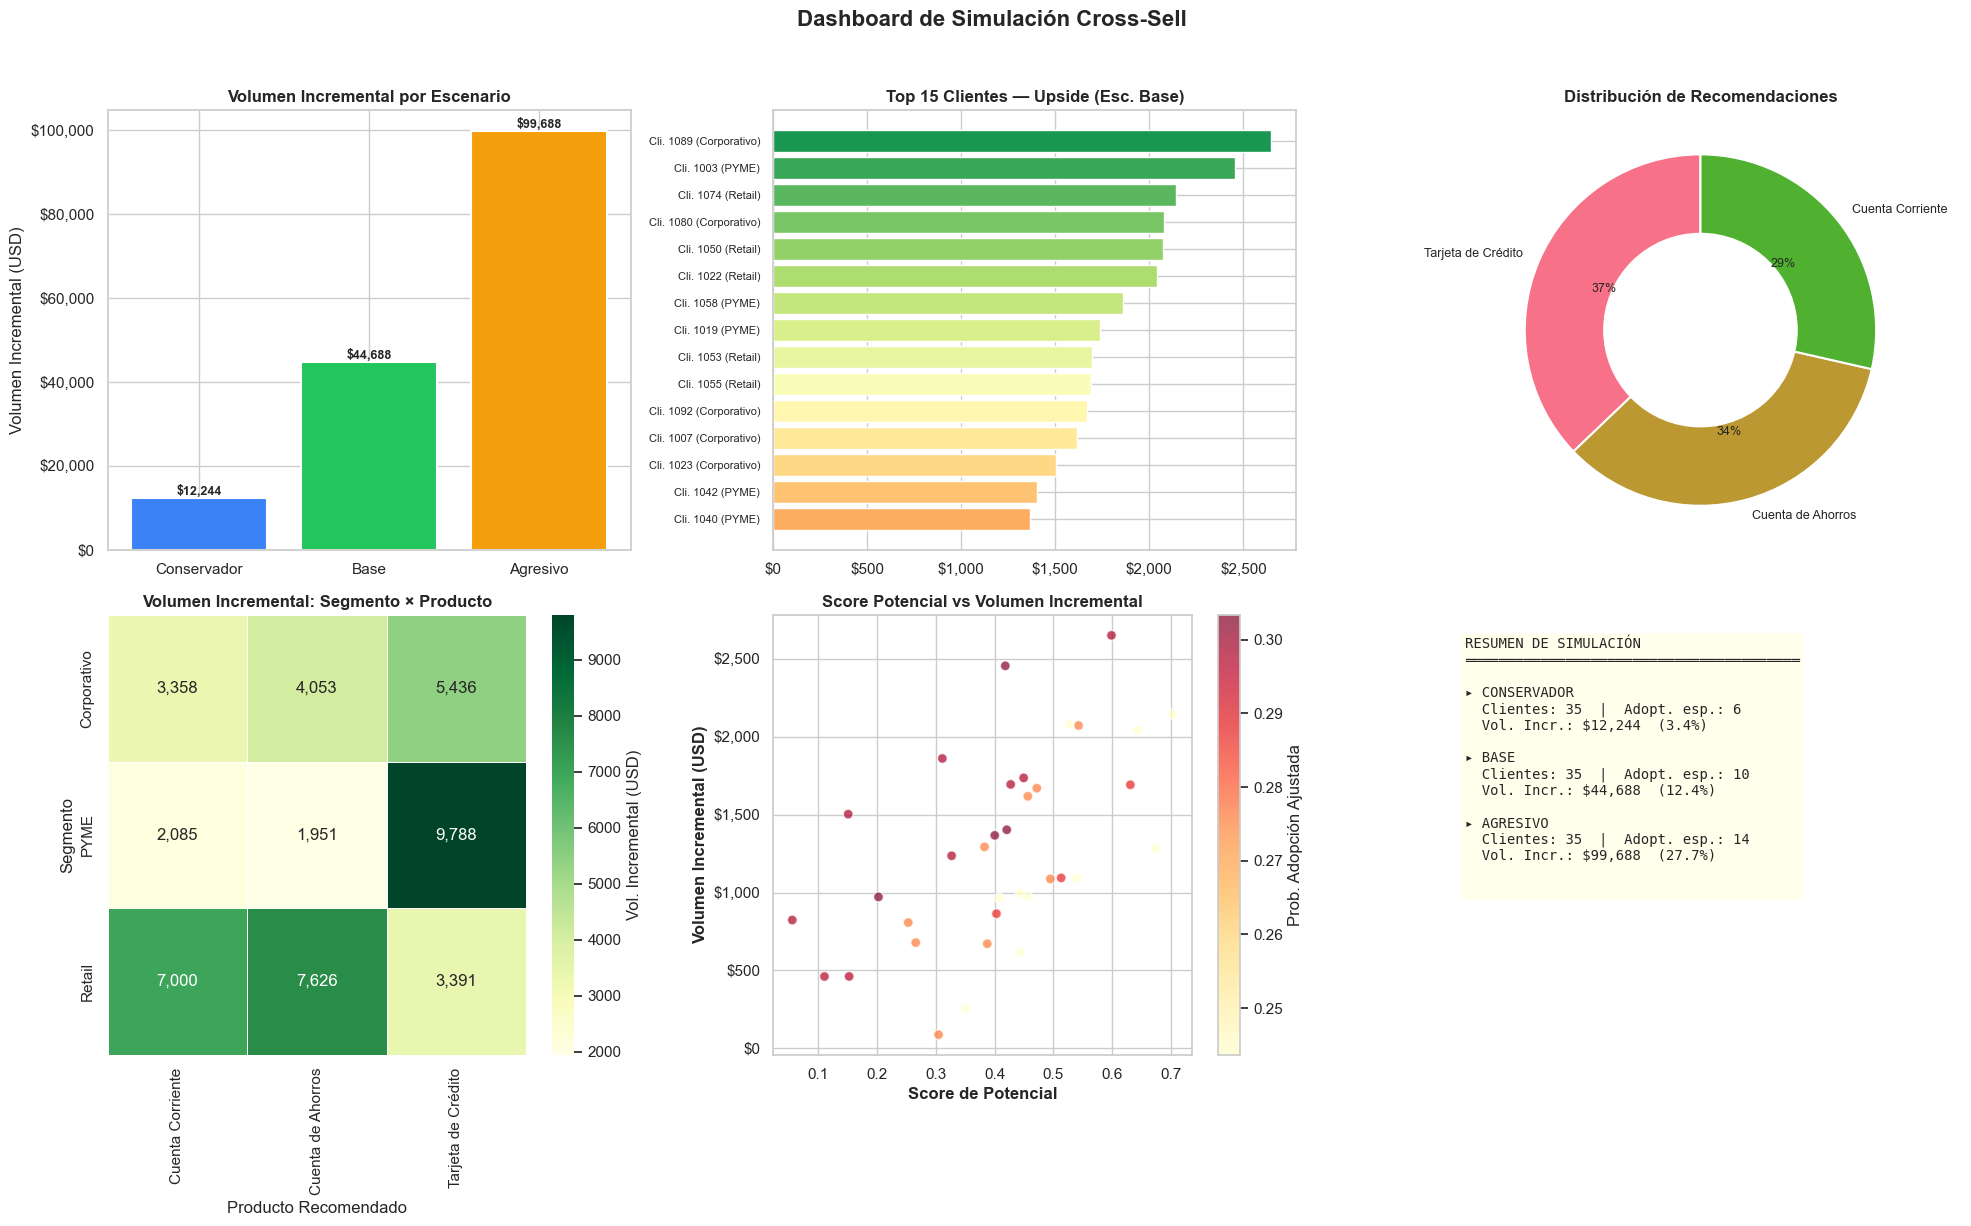

  📄 Resultados exportados a: simulacion_cross_sell.xlsx


In [24]:
# Simulador con filtros personalizables
filtros = FiltrosElegibilidad(max_productos=2, score_minimo=0.0)
sim = CrossSellSimulator(dominio, filtros=filtros)
# Diagnóstico previo
sim.diagnostico()
# Simular 3 escenarios
resultados = sim.simular_escenarios()
# Resúmenes
print(sim.resumen_ejecutivo(resultados))
print(sim.resumen_por_producto(resultados))
# Dashboard visual
sim.visualizar_resultados(resultados)
# Exportar a Excel
sim.exportar_excel(resultados, "simulacion_cross_sell.xlsx")